# SDV Models: Comprehensive Evaluation

This notebook contains a comprehensive evaluation of four synthetic data generation models:
1. **CTGAN** - Conditional Tabular GAN
2. **CopulaGAN** - GAN-based with copula modeling
3. **Gaussian Copula** - Statistical copula-based approach
4. **TVAE** - Tabular Variational Autoencoder

Each model is evaluated using multiple fidelity metrics including KS test, JS divergence, Wasserstein distance, and more.


## Data Loading and Setup


In [1]:
import pandas as pd

data = pd.read_csv(
    'C:/Users/Gopi.Battineni/OneDrive - University of Limerick/Desktop/FORGE/Synthetic-data_Audit/Datasets/bank-full.csv',
    sep=';'
)

print(data.head())
print(data.shape)

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  
(45211, 17)


In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Take first 10,000 rows
data = data.head(10000).reset_index(drop=True)

print(f"Sampled data shape: {data.shape}")
print(f"Columns: {list(data.columns)}")

Sampled data shape: (10000, 17)
Columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [3]:
from sklearn.preprocessing import OrdinalEncoder

cat_cols = data.select_dtypes(include='object').columns

encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

data[cat_cols] = encoder.fit_transform(data[cat_cols])

In [4]:
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,4.0,1.0,2.0,0.0,2143,1.0,0.0,0.0,5,1.0,261,1,-1,0,0.0,0.0
1,44,9.0,2.0,1.0,0.0,29,1.0,0.0,0.0,5,1.0,151,1,-1,0,0.0,0.0
2,33,2.0,1.0,1.0,0.0,2,1.0,1.0,0.0,5,1.0,76,1,-1,0,0.0,0.0
3,47,1.0,1.0,3.0,0.0,1506,1.0,0.0,0.0,5,1.0,92,1,-1,0,0.0,0.0
4,33,11.0,2.0,3.0,0.0,1,0.0,0.0,0.0,5,1.0,198,1,-1,0,0.0,0.0


## Helper Functions

Shared functions for evaluation metrics across all models.


In [5]:
from pandas.api.types import is_numeric_dtype
from scipy.spatial.distance import jensenshannon
from sklearn.preprocessing import MinMaxScaler

def _prob_vectors_numeric(real, synth, bins=30, eps=1e-12):
    """Convert numeric columns into comparable probability vectors."""
    real = pd.to_numeric(real, errors='coerce').dropna().to_numpy()
    synth = pd.to_numeric(synth, errors='coerce').dropna().to_numpy()

    edges = np.histogram_bin_edges(np.concatenate([real, synth]), bins=bins)
    r_hist, _ = np.histogram(real, bins=edges)
    s_hist, _ = np.histogram(synth, bins=edges)

    r = r_hist.astype(float) + eps
    s = s_hist.astype(float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s

def _prob_vectors_categorical(real, synth, eps=1e-12):
    """Convert categorical columns into comparable probability vectors."""
    r_counts = real.astype(str).value_counts(dropna=False)
    s_counts = synth.astype(str).value_counts(dropna=False)
    keys = r_counts.index.union(s_counts.index)
    r = r_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    s = s_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s, keys

def compute_js_divergence(real_df: pd.DataFrame,
                          synth_df: pd.DataFrame,
                          bins=30,
                          normalize=True) -> pd.DataFrame:
    """
    Compute Jensen–Shannon Divergence for each column between real and synthetic data.
    Returns a DataFrame with per-feature JS divergence values.
    """
    common_cols = [c for c in real_df.columns if c in synth_df.columns]
    real = real_df[common_cols].copy()
    synth = synth_df[common_cols].copy()

    # Optional normalization for numeric columns
    if normalize:
        num_cols = [c for c in common_cols if is_numeric_dtype(real[c])]
        scaler = MinMaxScaler()
        real[num_cols] = scaler.fit_transform(real[num_cols])
        synth[num_cols] = scaler.transform(synth[num_cols])

    results = []
    for col in common_cols:
        r_col, s_col = real[col], synth[col]

        if is_numeric_dtype(r_col):
            p, q = _prob_vectors_numeric(r_col, s_col, bins=bins)
        else:
            p, q, _ = _prob_vectors_categorical(r_col, s_col)

        # Jensen-Shannon divergence (base=2 → bounded [0,1])
        js_div = jensenshannon(p, q, base=2) ** 2

        results.append({"Feature": col, "JS_Divergence": js_div})

    return pd.DataFrame(results).sort_values("JS_Divergence")

In [6]:
from itertools import combinations
from scipy import stats
from sklearn.preprocessing import MinMaxScaler

def bivariate_quality_banking(real_df, synth_df, target='y'):
    """Compute bivariate quality metrics for cancer data."""
    num_cols = [c for c in real_df.columns if c != target]
    
    # Min-Max scaling on numeric columns
    scaler = MinMaxScaler()
    
    real_scaled = real_df.copy()
    synth_scaled = synth_df.copy()
    
    # Fit on real, transform both real and synthetic
    real_scaled[num_cols] = scaler.fit_transform(real_df[num_cols])
    synth_scaled[num_cols] = scaler.transform(synth_df[num_cols])
    
    results_corr = []
    results_target = []

    # Numeric-to-numeric: Δ-correlation
    for a, b in combinations(num_cols, 2):
        r_corr = real_scaled[[a, b]].corr().iloc[0, 1]
        s_corr = synth_scaled[[a, b]].corr().iloc[0, 1]
        results_corr.append({
            'var_a': a,
            'var_b': b,
            'delta_corr': abs(r_corr - s_corr)
        })
    
    # Numeric-to-target: Δ-Wasserstein between classes
    for col in num_cols:
        r_groups = [g[col].values for _, g in real_scaled.groupby(target)]
        s_groups = [g[col].values for _, g in synth_scaled.groupby(target)]
        
        if len(r_groups) == 2 and len(s_groups) == 2:
            d_real = stats.wasserstein_distance(*r_groups)
            d_synth = stats.wasserstein_distance(*s_groups)
            results_target.append({
                "feature": col,
                "delta_wasserstein": abs(d_real - d_synth)
            })

    corr_df = pd.DataFrame(results_corr).sort_values("delta_corr", ascending=False)
    target_df = pd.DataFrame(results_target).sort_values("delta_wasserstein", ascending=False)
    
    return corr_df, target_df

## Generating synthetic data

In [7]:
from sdv.metadata import SingleTableMetadata
from sdv.single_table import (
    CTGANSynthesizer,
    CopulaGANSynthesizer,
    GaussianCopulaSynthesizer,
    TVAESynthesizer
)
from sdv.evaluation.single_table import evaluate_quality, run_diagnostic

# -------- DROP TARGET VARIABLE --------
X_real = data.drop(columns=['y'])

# -------- CREATE METADATA (FEATURES ONLY) --------
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(X_real)

# -------- DEFINE MODELS --------
models = {
    "CTGAN": CTGANSynthesizer(metadata=metadata),
    "CopulaGAN": CopulaGANSynthesizer(metadata=metadata),
    "GaussianCopula": GaussianCopulaSynthesizer(metadata=metadata),
    "TVAE": TVAESynthesizer(metadata=metadata)
}

synthetic_data = {}
diagnostics = {}
quality_reports = {}

# -------- TRAIN, SAMPLE, EVALUATE --------
for name, model in models.items():
    model.fit(X_real)
    synthetic_data[name] = model.sample(num_rows=len(X_real))
    diagnostics[name] = run_diagnostic(X_real, synthetic_data[name], metadata)
    quality_reports[name] = evaluate_quality(X_real, synthetic_data[name], metadata)

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 16/16 [00:00<00:00, 937.63it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<?, ?it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 16/16 [00:00<00:00, 227.36it/s]|
Column Shapes Score: 92.8%

(2/2) Evaluating Column Pair Trends: |██████████| 120/120 [00:00<00:00, 295.89it/s]|
Column Pair Trends Score: 82.74%

Overall Score (Average): 87.77%

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 16/16 [00:00<00:00, 1012.28it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 200.04it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 16/16 [00:00<00:00, 270.89it/s]|
Column Shapes Score: 94.77%

(2/2) Evaluating Column Pair Trends: |██████████| 120/120

# KS Complement for 4 Models

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 16/16 [00:00<00:00, 276.10it/s]|
Column Shapes Score: 92.8%

(2/2) Evaluating Column Pair Trends: |██████████| 120/120 [00:00<00:00, 280.69it/s]|
Column Pair Trends Score: 82.74%

Overall Score (Average): 87.77%


CTGAN – KS Complement (Column Shapes)
       Column   Score
8     contact  1.0000
13      pdays  1.0000
14   previous  1.0000
15   poutcome  1.0000
4     default  0.9714
3   education  0.9560
7        loan  0.9496
0         age  0.9316
6     housing  0.9127
1         job  0.9092
10      month  0.9012
2     marital  0.8971
9         day  0.8914
11   duration  0.8670
5     balance  0.8644
12   campaign  0.7960
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 16/16 [00:00<00:00, 286.49it/s]|
Column Shapes Score: 94.77%

(2/2) Evaluating Column Pair Trends: |██████████| 120/120 [00:00<00:00, 276.15it/s]|
Column Pair Trends Score: 85.73%

Overall Score (Average): 90.25%


CopulaGAN – KS Compleme

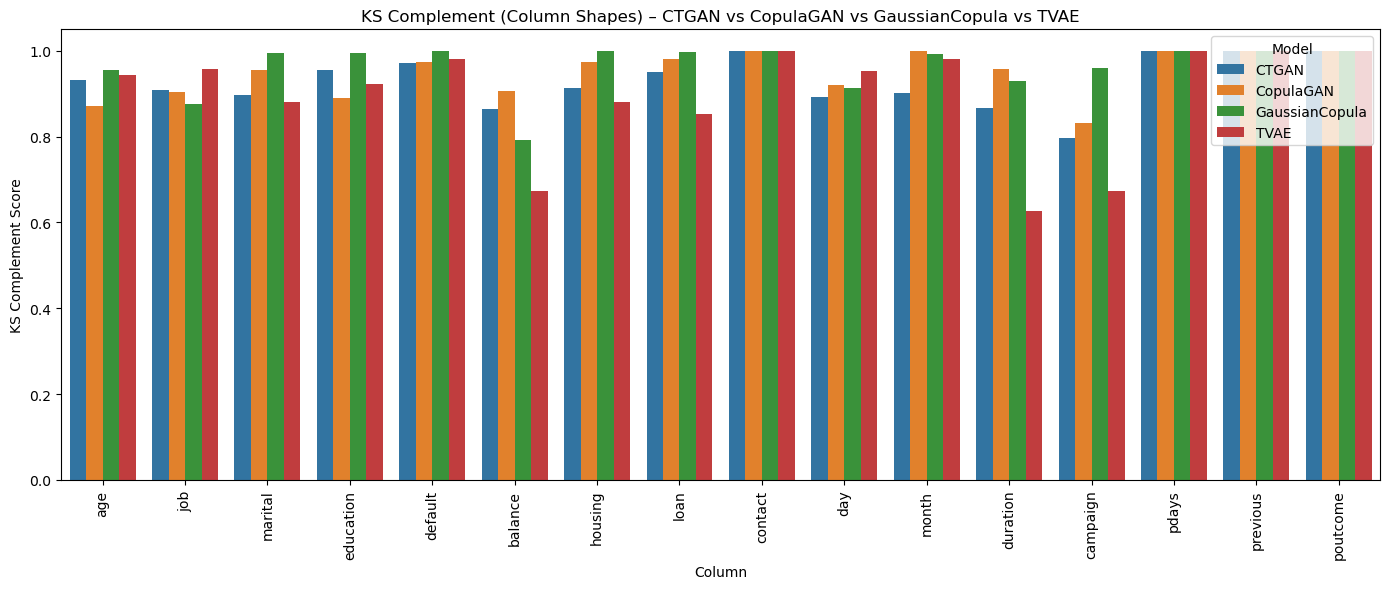

In [8]:
from sdv.evaluation.single_table import QualityReport
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -------- REAL FEATURES (already defined above, repeated for safety) --------
X_real = data.drop(columns=['y'])

all_scores = []

# -------- LOOP OVER THE 4 MODELS YOU ALREADY TRAINED --------
for model_name, synth_df in synthetic_data.items():

    qr = QualityReport()
    qr.generate(
        real_data=X_real,
        synthetic_data=synth_df,
        metadata=metadata.to_dict()
    )

    details = qr.get_details("Column Shapes")
    details["Model"] = model_name
    all_scores.append(details)

    # -------- PRINT SCORES FOR EACH MODEL --------
    print(f"\n{model_name} – KS Complement (Column Shapes)")
    print(details[["Column", "Score"]].sort_values("Score", ascending=False))

# -------- COMBINE RESULTS --------
ks_all = pd.concat(all_scores, ignore_index=True)

# -------- PLOT COMPARISON --------
plt.figure(figsize=(14, 6))
sns.barplot(
    data=ks_all,
    x="Column",
    y="Score",
    hue="Model"
)

plt.title("KS Complement (Column Shapes) – CTGAN vs CopulaGAN vs GaussianCopula vs TVAE")
plt.ylabel("KS Complement Score")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# JS Divergence per Feature – 4 Models


CTGAN – JS Divergence per Feature
      Feature  JS_Divergence  Model
5     balance       0.054877  CTGAN
12   campaign       0.049255  CTGAN
9         day       0.045455  CTGAN
11   duration       0.027121  CTGAN
1         job       0.018171  CTGAN
0         age       0.017819  CTGAN
10      month       0.009344  CTGAN
2     marital       0.009145  CTGAN
3   education       0.001913  CTGAN
4     default       0.000000  CTGAN
6     housing       0.000000  CTGAN
7        loan       0.000000  CTGAN
8     contact       0.000000  CTGAN
13      pdays       0.000000  CTGAN
14   previous       0.000000  CTGAN
15   poutcome       0.000000  CTGAN

CopulaGAN – JS Divergence per Feature
      Feature  JS_Divergence      Model
9         day       0.061961  CopulaGAN
5     balance       0.037454  CopulaGAN
1         job       0.036760  CopulaGAN
12   campaign       0.035695  CopulaGAN
0         age       0.031720  CopulaGAN
11   duration       0.017380  CopulaGAN
2     marital       0.001697  Copu

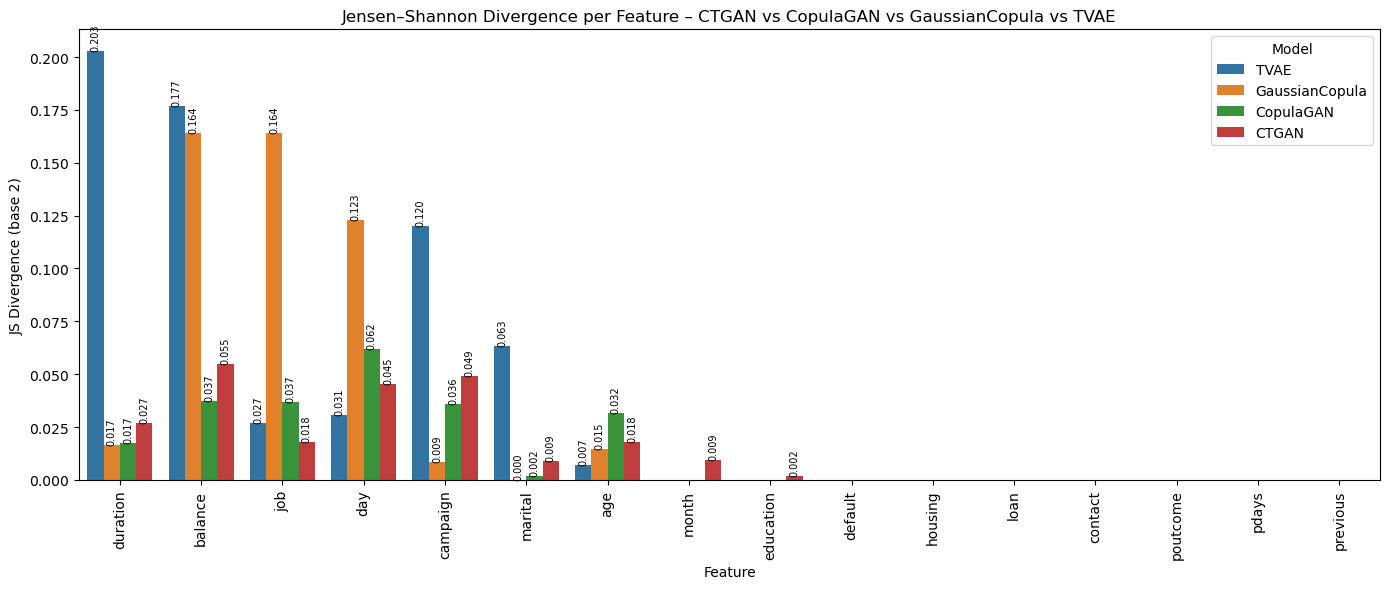

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -------- REAL FEATURES --------
X_real = data.drop(columns=['y'])

all_js = []

# -------- COMPUTE JS FOR EACH MODEL --------
for model_name, synth_df in synthetic_data.items():

    results_js = compute_js_divergence(
        X_real,
        synth_df,
        bins="fd",
        normalize=True
    )

    results_js["Model"] = model_name
    all_js.append(results_js)

    # -------- PRINT RESULTS --------
    print(f"\n{model_name} – JS Divergence per Feature")
    print(results_js.sort_values("JS_Divergence", ascending=False))

# -------- COMBINE RESULTS --------
js_all = pd.concat(all_js, ignore_index=True)

# -------- SORT BY WORST FEATURES (overall) --------
js_all_sorted = js_all.sort_values("JS_Divergence", ascending=False)

# -------- PLOT --------
plt.figure(figsize=(14, 6))
bars = sns.barplot(
    data=js_all_sorted,
    x="Feature",
    y="JS_Divergence",
    hue="Model"
)

for bar in bars.patches:
    yval = bar.get_height()
    if yval > 0:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            yval,
            f"{yval:.3f}",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90
        )

plt.xticks(rotation=90)
plt.ylabel("JS Divergence (base 2)")
plt.title("Jensen–Shannon Divergence per Feature – CTGAN vs CopulaGAN vs GaussianCopula vs TVAE")
plt.tight_layout()
plt.show()

# Wasserstein Distance per Numeric Feature

In [10]:
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# -------- REAL FEATURES (drop y) --------
X_real = data.drop(columns=['y'])

# -------- NUMERIC COLUMNS ONLY --------
num_cols = X_real.select_dtypes(include=['int64', 'float64']).columns
real_num = X_real[num_cols].copy()

all_wasserstein = []

# -------- LOOP OVER ALL 4 MODELS --------
for model_name, synth_df in synthetic_data.items():

    synthetic_num = synth_df[num_cols].copy()

    # -------- SCALE (fit ONLY on real) --------
    scaler = MinMaxScaler()
    real_scaled = pd.DataFrame(
        scaler.fit_transform(real_num),
        columns=num_cols
    )
    synth_scaled = pd.DataFrame(
        scaler.transform(synthetic_num),
        columns=num_cols
    )

    # -------- COMPUTE WASSERSTEIN --------
    print(f"\n{model_name} – Wasserstein Distance (Features Only)")
    for col in num_cols:
        dist = wasserstein_distance(
            real_scaled[col],
            synth_scaled[col]
        )
        print(f"{col}: {dist:.4f}")

        all_wasserstein.append({
            "Model": model_name,
            "Feature": col,
            "Wasserstein": dist
        })

# -------- COMBINED RESULTS TABLE --------
wasserstein_all = pd.DataFrame(all_wasserstein)


CTGAN – Wasserstein Distance (Features Only)
age: 0.0367
job: 0.0534
marital: 0.0515
education: 0.0188
default: 0.0286
balance: 0.0035
housing: 0.0873
loan: 0.0504
contact: 0.0000
day: 0.0451
month: 0.0988
duration: 0.0105
campaign: 0.0084
pdays: 0.0000
previous: 0.0000
poutcome: 0.0000

CopulaGAN – Wasserstein Distance (Features Only)
age: 0.0365
job: 0.0317
marital: 0.0222
education: 0.0413
default: 0.0258
balance: 0.0062
housing: 0.0260
loan: 0.0194
contact: 0.0000
day: 0.0391
month: 0.0007
duration: 0.0092
campaign: 0.0119
pdays: 0.0000
previous: 0.0000
poutcome: 0.0000

GaussianCopula – Wasserstein Distance (Features Only)
age: 0.0203
job: 0.0578
marital: 0.0040
education: 0.0020
default: 0.0015
balance: 0.0123
housing: 0.0011
loan: 0.0026
contact: 0.0000
day: 0.0221
month: 0.0071
duration: 0.0075
campaign: 0.0044
pdays: 0.0000
previous: 0.0000
poutcome: 0.0000

TVAE – Wasserstein Distance (Features Only)
age: 0.0179
job: 0.0210
marital: 0.0613
education: 0.0389
default: 0.0198
b

# Gower Similarity

In [11]:
import gower
import numpy as np
import pandas as pd

# -------- REAL FEATURES (drop y) --------
X_real = data.drop(columns=['y'])

gower_results = []

# -------- LOOP OVER ALL 4 MODELS --------
for model_name, X_synth in synthetic_data.items():

    # -------- Gower SIMILARITY MATRICES --------
    gower_real = 1 - gower.gower_matrix(X_real)
    gower_synth = 1 - gower.gower_matrix(X_synth)

    # -------- TRUE CROSS-SET SIMILARITY --------
    gower_cross = 1 - gower.gower_matrix(X_real, X_synth)

    # -------- Intra-set statistics --------
    real_upper = gower_real[np.triu_indices_from(gower_real, k=1)]
    synth_upper = gower_synth[np.triu_indices_from(gower_synth, k=1)]

    max_intra_real = np.max(real_upper)
    avg_intra_real = np.mean(real_upper)

    max_intra_synth = np.max(synth_upper)
    avg_intra_synth = np.mean(synth_upper)

    # -------- Cross-set statistics --------
    max_cross = np.max(gower_cross)
    avg_cross = np.mean(gower_cross)

    # -------- Store results --------
    gower_results.append({
        "Model": model_name,
        "Max_Intra_Real": max_intra_real,
        "Avg_Intra_Real": avg_intra_real,
        "Max_Intra_Synth": max_intra_synth,
        "Avg_Intra_Synth": avg_intra_synth,
        "Max_Cross": max_cross,
        "Avg_Cross": avg_cross
    })

    # -------- Print report --------
    print(f"\n{model_name} – Gower Similarity (Features Only)")
    print("Intra-set Similarity (Real):")
    print(f"Max = {max_intra_real:.4f}, Avg = {avg_intra_real:.4f}\n")

    print("Intra-set Similarity (Synthetic):")
    print(f"Max = {max_intra_synth:.4f}, Avg = {avg_intra_synth:.4f}\n")

    print("Cross-set Similarity (Real ↔ Synthetic):")
    print(f"Max = {max_cross:.4f}, Avg = {avg_cross:.4f}")

# -------- COMBINED RESULTS TABLE --------
gower_summary = pd.DataFrame(gower_results)



CTGAN – Gower Similarity (Features Only)
Intra-set Similarity (Real):
Max = 1.0000, Avg = 0.8419

Intra-set Similarity (Synthetic):
Max = 1.0000, Avg = 0.8206

Cross-set Similarity (Real ↔ Synthetic):
Max = 0.9999, Avg = 0.8401

CopulaGAN – Gower Similarity (Features Only)
Intra-set Similarity (Real):
Max = 1.0000, Avg = 0.8419

Intra-set Similarity (Synthetic):
Max = 0.9999, Avg = 0.8365

Cross-set Similarity (Real ↔ Synthetic):
Max = 0.9999, Avg = 0.8522

GaussianCopula – Gower Similarity (Features Only)
Intra-set Similarity (Real):
Max = 1.0000, Avg = 0.8419

Intra-set Similarity (Synthetic):
Max = 0.9977, Avg = 0.8255

Cross-set Similarity (Real ↔ Synthetic):
Max = 0.9996, Avg = 0.8499

TVAE – Gower Similarity (Features Only)
Intra-set Similarity (Real):
Max = 1.0000, Avg = 0.8419

Intra-set Similarity (Synthetic):
Max = 1.0000, Avg = 0.8558

Cross-set Similarity (Real ↔ Synthetic):
Max = 1.0000, Avg = 0.8739


# t-SNE (Real vs Synthetic)

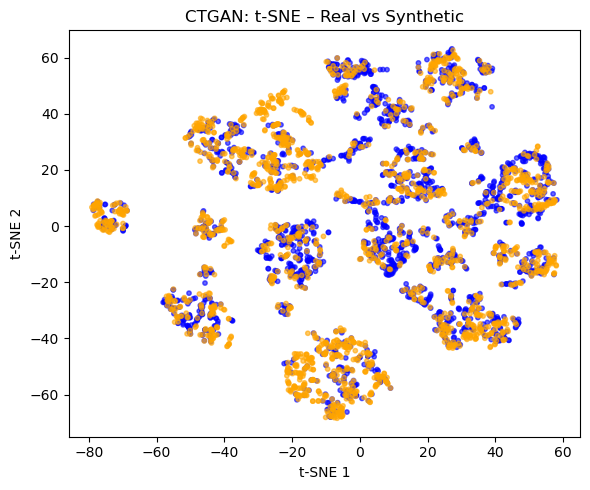

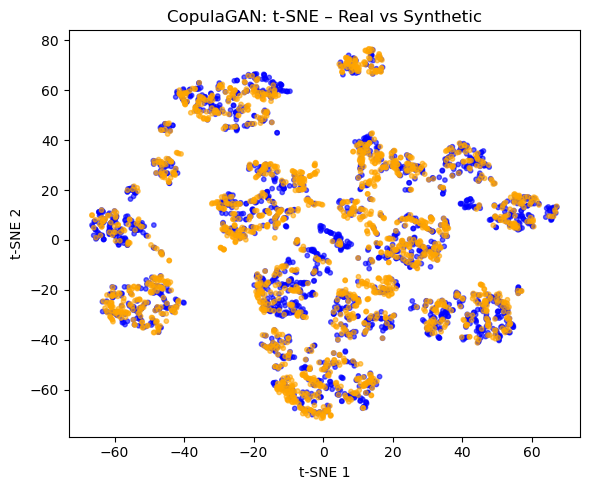

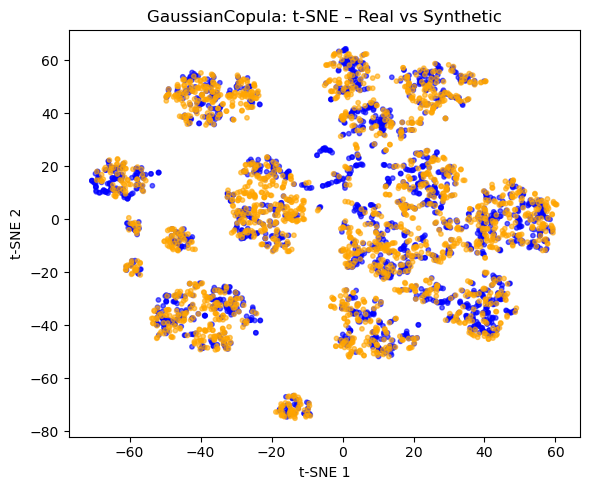

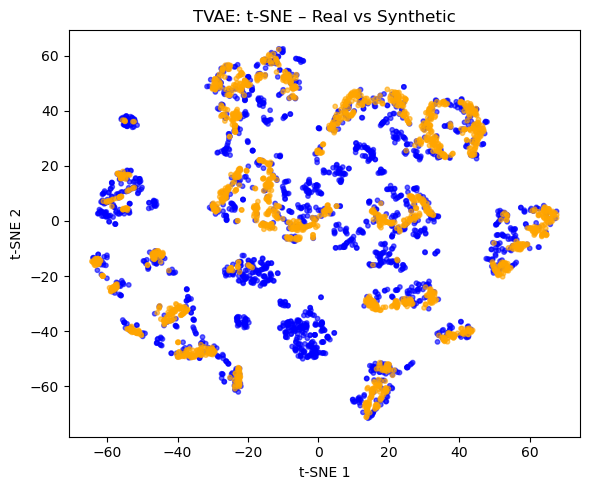

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.manifold import TSNE

# -----------------------------
# Settings
# -----------------------------
RANDOM_STATE = 42
N = 2000
np.random.seed(RANDOM_STATE)

# -----------------------------
# REAL FEATURES
# -----------------------------
X_real = data.drop(columns=['y'])

# -----------------------------
# Loop over models
# -----------------------------
for model_name, X_synth_full in synthetic_data.items():

    # -----------------------------
    # Subsample
    # -----------------------------
    real_tsne = X_real.sample(n=N, random_state=RANDOM_STATE)
    synth_tsne = X_synth_full.sample(n=N, random_state=RANDOM_STATE)

    # -----------------------------
    # Identify columns
    # -----------------------------
    cat_cols = real_tsne.select_dtypes(include='object').columns.tolist()
    num_cols = real_tsne.select_dtypes(exclude='object').columns.tolist()

    # -----------------------------
    # Impute numeric
    # -----------------------------
    num_imputer = SimpleImputer(strategy='median')
    real_num = num_imputer.fit_transform(real_tsne[num_cols])
    synth_num = num_imputer.transform(synth_tsne[num_cols])

    # -----------------------------
    # Encode categorical (ONLY IF EXISTS)
    # -----------------------------
    if len(cat_cols) > 0:
        cat_imputer = SimpleImputer(strategy='most_frequent')
        real_cat = cat_imputer.fit_transform(real_tsne[cat_cols])
        synth_cat = cat_imputer.transform(synth_tsne[cat_cols])

        encoder = OrdinalEncoder(
            handle_unknown='use_encoded_value',
            unknown_value=-1
        )

        real_cat = encoder.fit_transform(real_cat)
        synth_cat = encoder.transform(synth_cat)

        real_all = np.hstack([real_num, real_cat])
        synth_all = np.hstack([synth_num, synth_cat])
    else:
        # No categorical features
        real_all = real_num
        synth_all = synth_num

    # -----------------------------
    # Scale
    # -----------------------------
    scaler = StandardScaler()
    real_scaled = scaler.fit_transform(real_all)
    synth_scaled = scaler.transform(synth_all)

    # -----------------------------
    # Combine
    # -----------------------------
    combined = np.vstack([real_scaled, synth_scaled])
    labels = np.array(
        ['Real'] * len(real_scaled) +
        ['Synthetic'] * len(synth_scaled)
    )

    # -----------------------------
    # t-SNE
    # -----------------------------
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate='auto',
        init='pca',
        random_state=RANDOM_STATE
    )

    tsne_result = tsne.fit_transform(combined)

    # -----------------------------
    # Plot
    # -----------------------------
    plt.figure(figsize=(6, 5))
    colors = np.where(labels == 'Real', 'blue', 'orange')

    plt.scatter(
        tsne_result[:, 0],
        tsne_result[:, 1],
        c=colors,
        alpha=0.6,
        s=10
    )

    plt.title(f"{model_name}: t-SNE – Real vs Synthetic")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.tight_layout()
    plt.show()

# MMD (Maximum Mean Discrepancy)


In [13]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# -----------------------------
# REAL FEATURES (drop y)
# -----------------------------
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
num_cols = [c for c in num_cols if c != 'y']

real_num = data[num_cols].values

# -----------------------------
# Linear-time RBF MMD
# -----------------------------
def linear_mmd(x, y, sigma=1.0, random_state=42):
    rng = np.random.default_rng(random_state)

    n = min(len(x), len(y))
    n = n - (n % 2)  # force even

    idx_x = rng.choice(len(x), n, replace=False)
    idx_y = rng.choice(len(y), n, replace=False)

    x = x[idx_x]
    y = y[idx_y]

    x1, x2 = x[0::2], x[1::2]
    y1, y2 = y[0::2], y[1::2]

    def rbf(a, b):
        return np.exp(-np.sum((a - b) ** 2, axis=1) / (2 * sigma ** 2))

    k_xx = np.mean(rbf(x1, x2))
    k_yy = np.mean(rbf(y1, y2))
    k_xy = np.mean(rbf(x1, y2))

    return k_xx + k_yy - 2 * k_xy

# -----------------------------
# Compute MMD for ALL MODELS
# -----------------------------
print("Linear MMD (Features Only):")

for model_name, synth_df in synthetic_data.items():

    synthetic_num = synth_df[num_cols].values

    # -------- Standardize (fit on real only) --------
    scaler = StandardScaler()
    real_scaled = scaler.fit_transform(real_num)
    synthetic_scaled = scaler.transform(synthetic_num)

    mmd_score = linear_mmd(
        real_scaled,
        synthetic_scaled,
        sigma=1.0,
        random_state=42
    )

    print(f"{model_name}: {mmd_score:.6f}")


Linear MMD (Features Only):
CTGAN: 0.001910
CopulaGAN: 0.002077
GaussianCopula: 0.000831
TVAE: 0.021564


# Cosine Similarity


In [14]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

# -----------------------------
# REAL FEATURES (numeric only, drop y)
# -----------------------------
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
num_cols = [c for c in num_cols if c != 'y']

real_num = data[num_cols].values

print("Sample-Level Cosine Similarity (Features Only):")

# -----------------------------
# Loop over all models
# -----------------------------
for model_name, synth_df in synthetic_data.items():

    synthetic_num = synth_df[num_cols].values

    # -------- Standardize (fit on real only) --------
    scaler = StandardScaler()
    real_scaled = scaler.fit_transform(real_num)
    synthetic_scaled = scaler.transform(synthetic_num)

    # -------- Ensure equal sample size --------
    n = min(len(real_scaled), len(synthetic_scaled))
    real_scaled_n = real_scaled[:n]
    synthetic_scaled_n = synthetic_scaled[:n]

    # -------- Cosine similarity --------
    cross_sim = cosine_similarity(real_scaled_n, synthetic_scaled_n)

    avg_sim = np.mean(cross_sim)
    max_sim = np.max(cross_sim)

    print(f"\n{model_name}:")
    print(f"Average cosine similarity: {avg_sim:.4f}")
    print(f"Maximum cosine similarity: {max_sim:.4f}")


Sample-Level Cosine Similarity (Features Only):

CTGAN:
Average cosine similarity: 0.0033
Maximum cosine similarity: 1.0000

CopulaGAN:
Average cosine similarity: 0.0098
Maximum cosine similarity: 0.9999

GaussianCopula:
Average cosine similarity: 0.0054
Maximum cosine similarity: 0.9997

TVAE:
Average cosine similarity: 0.0303
Maximum cosine similarity: 1.0000


# Privacy Check


In [15]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

# -----------------------------
# REAL FEATURES (numeric only, drop y)
# -----------------------------
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
num_cols = [c for c in num_cols if c != 'y']

real_num = data[num_cols].values

print("Nearest-Neighbor Privacy Check (Numeric Features):")

# -----------------------------
# Loop over all models
# -----------------------------
for model_name, synth_df in synthetic_data.items():

    synthetic_num = synth_df[num_cols].values

    # -------- Standardize (fit on real only) --------
    scaler = StandardScaler()
    real_scaled = scaler.fit_transform(real_num)
    synthetic_scaled = scaler.transform(synthetic_num)

    # -------- Ensure dimensionality match --------
    assert real_scaled.shape[1] == synthetic_scaled.shape[1]

    # -------- Fit NN on REAL, query SYNTHETIC --------
    nn = NearestNeighbors(
        n_neighbors=1,
        metric="euclidean"
    ).fit(real_scaled)

    distances, _ = nn.kneighbors(synthetic_scaled)

    avg_nn_dist = distances.mean()
    min_nn_dist = distances.min()

    # -------- Report --------
    print(f"\n{model_name}:")
    print(f"Average NN Distance (Synthetic → Real): {avg_nn_dist:.4f}")
    print(f"Minimum NN Distance (Worst Case): {min_nn_dist:.4f}")

Nearest-Neighbor Privacy Check (Numeric Features):

CTGAN:
Average NN Distance (Synthetic → Real): 0.8728
Minimum NN Distance (Worst Case): 0.0255

CopulaGAN:
Average NN Distance (Synthetic → Real): 0.7543
Minimum NN Distance (Worst Case): 0.0310

GaussianCopula:
Average NN Distance (Synthetic → Real): 0.9979
Minimum NN Distance (Worst Case): 0.0598

TVAE:
Average NN Distance (Synthetic → Real): 0.3413
Minimum NN Distance (Worst Case): 0.0076


# Bivariate Quality (Δ-Correlation & Δ-Wasserstein)

In [16]:
# ------------------------------------
# Numeric columns EXCEPT target
# ------------------------------------
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
num_cols = [c for c in num_cols if c != 'y']

real_num = data[num_cols + ['y']].copy()

# ------------------------------------
# Loop over all models
# ------------------------------------
for model_name, synth_df in synthetic_data.items():

    # -------- Re-attach y to synthetic --------
    synth_num = synth_df[num_cols].copy()
    synth_num['y'] = data['y'].values

    # -------- Ensure column alignment --------
    synth_num = synth_num[real_num.columns]

    # -------- Bivariate metrics --------
    corr_results, target_results = bivariate_quality_banking(
        real_df=real_num,
        synth_df=synth_num
    )

    # -------- Display results --------
    print(f"\n{model_name} – Largest differences in pairwise correlations:")
    print(corr_results.head(10))

    print("\n--------------------------------")
    print(f"{model_name} – Features that differ most by target class:")
    print(target_results.head(10))



CTGAN – Largest differences in pairwise correlations:
       var_a      var_b  delta_corr
78   housing      month    0.385015
32   marital    housing    0.177401
36   marital      month    0.174243
101      day   campaign    0.168661
106    month   campaign    0.128769
68   balance        day    0.112081
77   housing        day    0.101662
1        age    marital    0.097530
29   marital  education    0.093599
35   marital        day    0.088362

--------------------------------
CTGAN – Features that differ most by target class:
     feature  delta_wasserstein
11  duration           0.172091
2    marital           0.041355
10     month           0.033782
7       loan           0.022620
0        age           0.019209
6    housing           0.013161
9        day           0.003234
1        job           0.002541
4    default           0.001421
5    balance           0.001412

CopulaGAN – Largest differences in pairwise correlations:
        var_a      var_b  delta_corr
78    housing   

# Correlation Heatmaps & |Δρ|


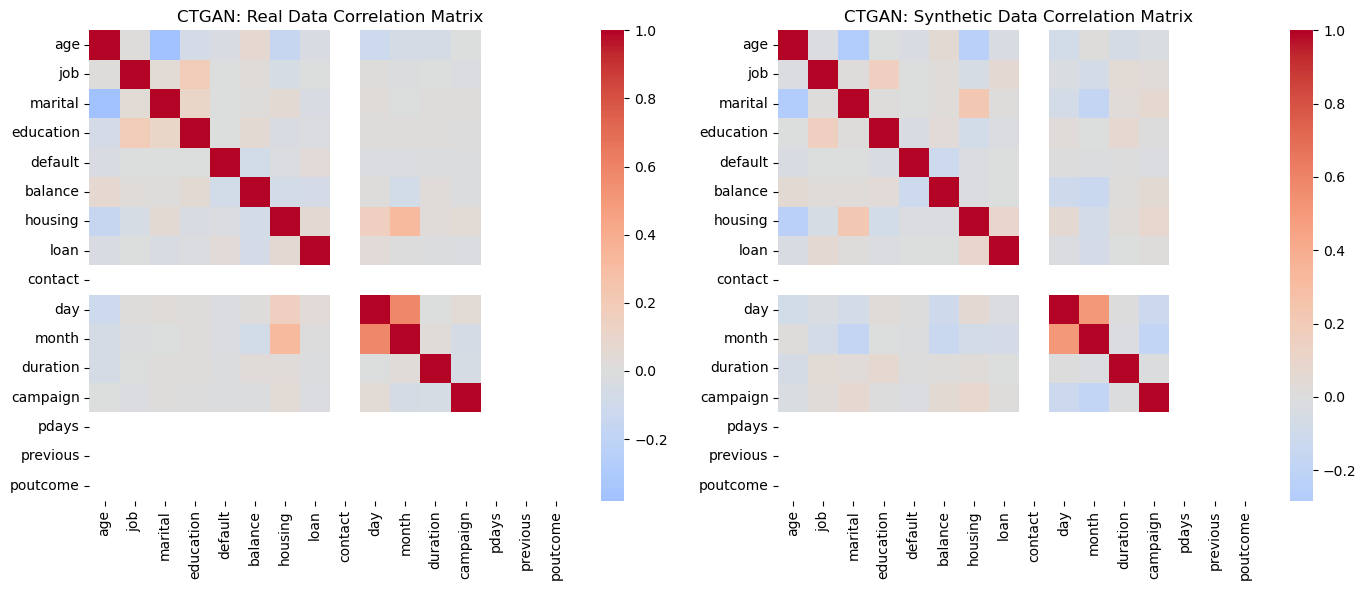

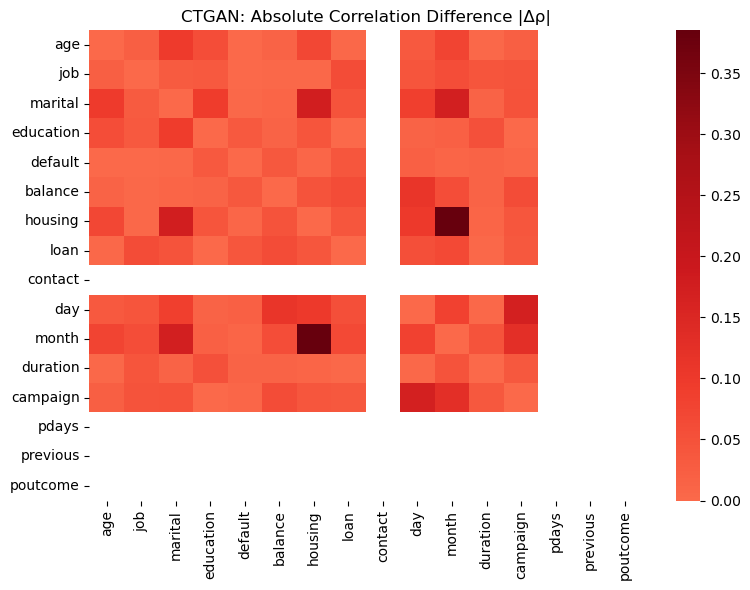

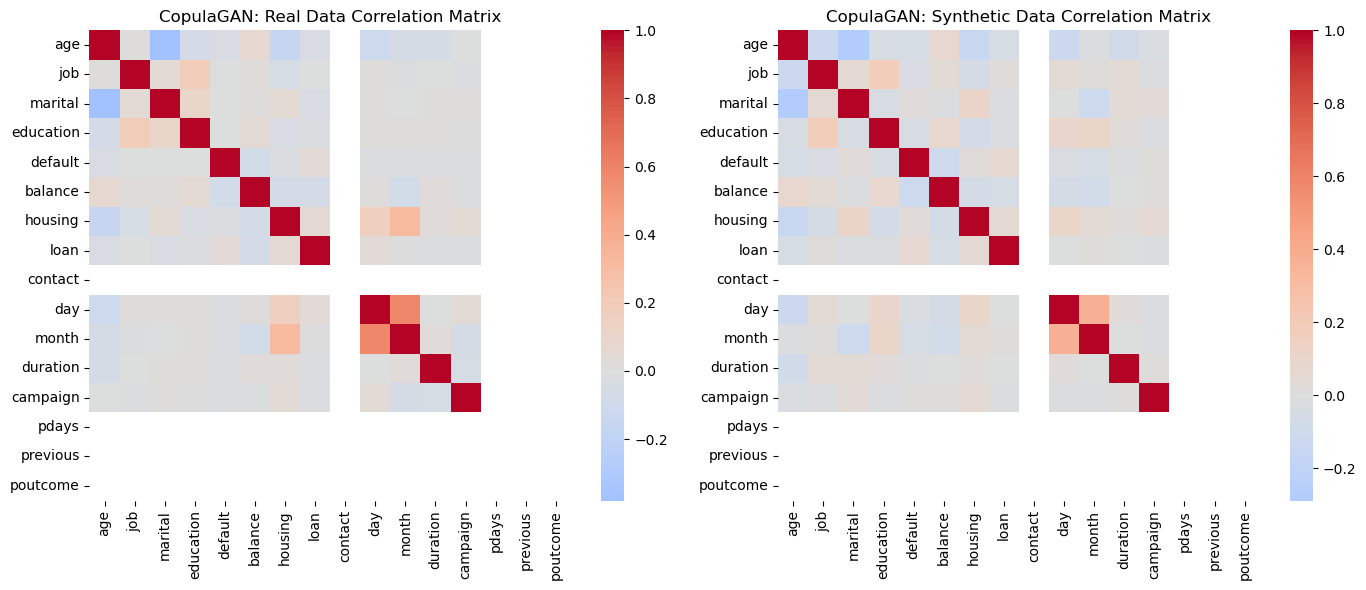

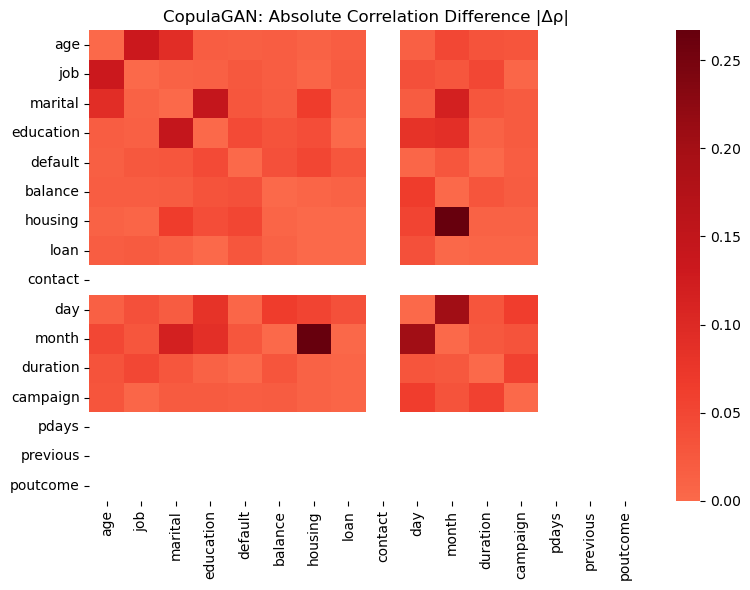

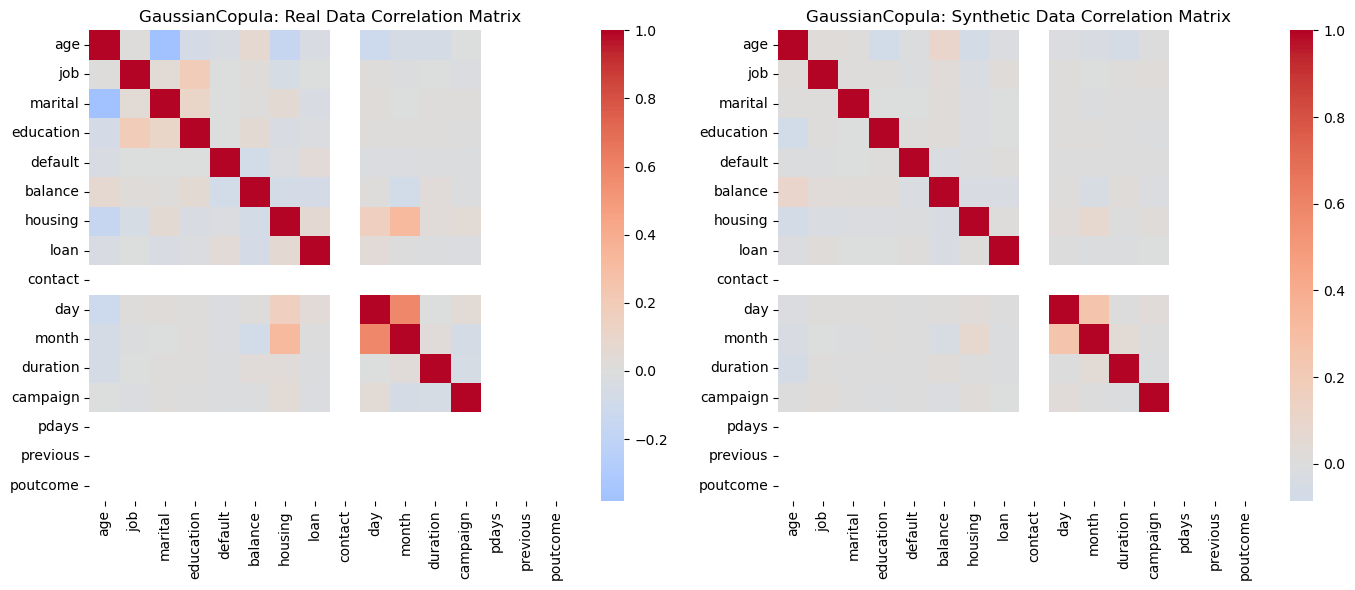

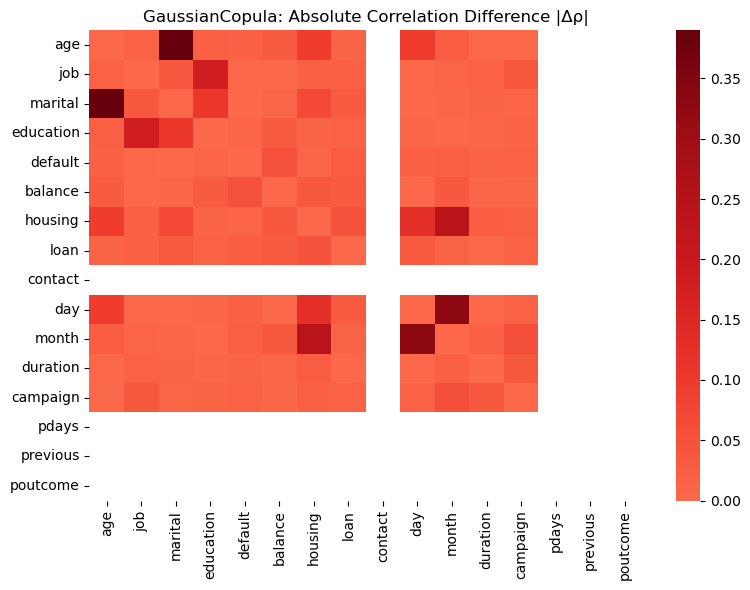

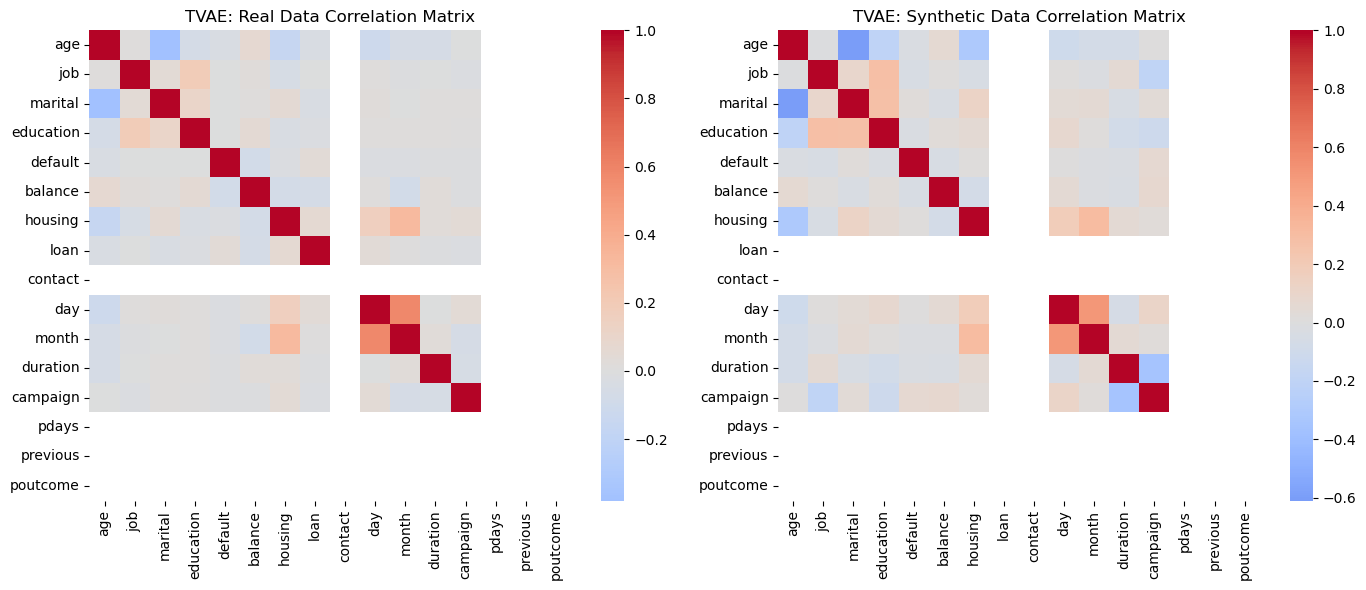

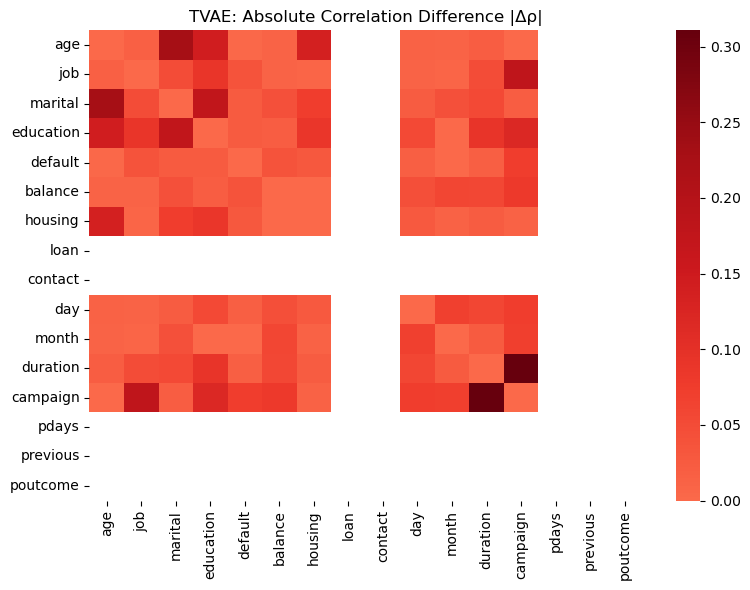

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------
# Numeric columns (exclude target)
# ------------------------------------
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
num_cols = [c for c in num_cols if c != 'y']

real_df = data[num_cols]

# ------------------------------------
# Loop over all models
# ------------------------------------
for model_name, synth_df in synthetic_data.items():

    synth_df_num = synth_df[num_cols]

    # ------------------------------------
    # Correlation heatmaps (Real vs Synthetic)
    # ------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    sns.heatmap(
        real_df.corr(),
        cmap="coolwarm",
        center=0,
        ax=axes[0]
    )
    axes[0].set_title(f"{model_name}: Real Data Correlation Matrix")

    sns.heatmap(
        synth_df_num.corr(),
        cmap="coolwarm",
        center=0,
        ax=axes[1]
    )
    axes[1].set_title(f"{model_name}: Synthetic Data Correlation Matrix")

    plt.tight_layout()
    plt.show()

    # ------------------------------------
    # Absolute correlation difference |Δρ|
    # ------------------------------------
    diff_corr = (real_df.corr() - synth_df_num.corr()).abs()

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        diff_corr,
        cmap="Reds",
        center=0
    )
    plt.title(f"{model_name}: Absolute Correlation Difference |Δρ|")
    plt.tight_layout()
    plt.show()

# Utility with 10 classifiers 

In [22]:
# ==========================================
# SYNTHETIC DATA GENERATION (WITH LABEL y)
# 1000 SAMPLES — CTGAN | CopulaGAN | GaussianCopula | TVAE
# ==========================================

from sdv.single_table import (
    CTGANSynthesizer,
    CopulaGANSynthesizer,
    GaussianCopulaSynthesizer,
    TVAESynthesizer
)
from sdv.metadata import SingleTableMetadata

# -----------------------------
# SETTINGS
# -----------------------------
label_col = "y"
num_rows = 1000    


# -----------------------------
# METADATA (CRITICAL)
# -----------------------------
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data)

# Mark target as categorical
metadata.update_column(
    column_name=label_col,
    sdtype="categorical"
)

# -----------------------------
# MODELS
# -----------------------------
synth_models = {
    "CTGAN": CTGANSynthesizer(
        metadata
    ),
    "CopulaGAN": CopulaGANSynthesizer(
        metadata        
    ),
    "GaussianCopula": GaussianCopulaSynthesizer(
        metadata        
    ),
    "TVAE": TVAESynthesizer(
        metadata
    )
}

# -----------------------------
# FIT & SAMPLE
# -----------------------------
synthetic_data = {}

for name, model in synth_models.items():
    print(f"\nTraining {name}...")
    model.fit(data)

    print(f"Sampling {num_rows} rows from {name}...")
    synth_df = model.sample(num_rows)

    # Sanity check
    if label_col not in synth_df.columns:
        raise RuntimeError(f"{name} failed to generate label column")

    print(f"{name} label distribution:")
    print(synth_df[label_col].value_counts())

    synthetic_data[name] = synth_df

print("\n✅ Synthetic data generation completed (1000 samples each).")


Training CTGAN...
Sampling 1000 rows from CTGAN...
CTGAN label distribution:
y
0.0    926
1.0     74
Name: count, dtype: int64

Training CopulaGAN...
Sampling 1000 rows from CopulaGAN...
CopulaGAN label distribution:
y
0.0    950
1.0     50
Name: count, dtype: int64

Training GaussianCopula...
Sampling 1000 rows from GaussianCopula...
GaussianCopula label distribution:
y
0.0    967
1.0     33
Name: count, dtype: int64

Training TVAE...
Sampling 1000 rows from TVAE...
TVAE label distribution:
y
0.0    1000
Name: count, dtype: int64

✅ Synthetic data generation completed (1000 samples each).


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier


models = { 

    'LogReg': LogisticRegression(max_iter=5000, solver='liblinear', random_state=42),
    'SVM-RBF': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(),
    'NaiveBayes': GaussianNB(),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'ExtraTrees':  ExtraTreesClassifier(random_state=42),
    'GradientBoost': GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "MLP": MLPClassifier(max_iter=2000, random_state=42),
}

In [24]:
# ===============================
# FIXED TRTR / TSTR EVALUATION
# ===============================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

# -----------------------------
# Evaluation function
# -----------------------------
def evaluate_models_fixed(train_df, test_df, label_col, models):
    X_train = train_df.drop(columns=[label_col])
    y_train = train_df[label_col]

    X_test = test_df.drop(columns=[label_col])
    y_test = test_df[label_col]

    # Impute
    imputer = SimpleImputer(strategy="median")
    X_train = imputer.fit_transform(X_train)
    X_test  = imputer.transform(X_test)

    # Scale
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    rows = []
    for name, clf in models.items():
        clf.fit(X_train, y_train)

        y_pred = clf.predict(X_test)

        if hasattr(clf, "predict_proba"):
            y_prob = clf.predict_proba(X_test)[:, 1]
        elif hasattr(clf, "decision_function"):
            scores = clf.decision_function(X_test)
            y_prob = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)
        else:
            y_prob = None

        rows.append({
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "F1": f1_score(y_test, y_pred, zero_division=0),
            "AUC": roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan
        })

    return pd.DataFrame(rows)

# -----------------------------
# SETTINGS
# -----------------------------
label_col = "y"
seed = 42

# -----------------------------
# SINGLE REAL TRAIN / TEST SPLIT
# -----------------------------
real_train, real_test = train_test_split(
    data,
    test_size=0.2,
    random_state=seed,
    stratify=data[label_col]
)

# -----------------------------
# TRTR (Real → Real)
# -----------------------------
trtr = evaluate_models_fixed(
    train_df=real_train,
    test_df=real_test,
    label_col=label_col,
    models=models
)
trtr = trtr.add_suffix("_TRTR")
trtr["Model"] = trtr.index

# -----------------------------
# TSTR (Synthetic → Real)
# synthetic_data[gan] MUST contain column "y"
# -----------------------------
all_results = []

for gan_name, synth_df in synthetic_data.items():

    if label_col not in synth_df.columns:
        raise ValueError(f"{gan_name} synthetic data does NOT contain labels")

    tstr = evaluate_models_fixed(
        train_df=synth_df,
        test_df=real_test,
        label_col=label_col,
        models=models
    )

    tstr = tstr.add_suffix("_TSTR")
    tstr["Model"] = tstr.index
    tstr["GAN"] = gan_name

    comparison = trtr.merge(tstr, on="Model")
    comparison["AUC_Drop"] = comparison["AUC_TRTR"] - comparison["AUC_TSTR"]

    all_results.append(comparison)

# -----------------------------
# FINAL UTILITY TABLE
# -----------------------------
utility_comparison = (
    pd.concat(all_results, ignore_index=True)
      .sort_values(["GAN", "AUC_Drop"], ascending=[True, False])
)

utility_comparison

ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: 0.0

In [23]:
label_col = "y"

# -----------------------------
# TRTR (Train Real → Test Real)
# -----------------------------
trtr_results = evaluate_models(
    train_df=data,
    test_df=data,
    label_col=label_col,
    models=models
)

all_comparisons = []

# -----------------------------
# TSTR for each GAN
# -----------------------------
for gan_name, synth_X in synthetic_data.items():

    # Re-attach real labels to synthetic features
    synth_with_y = synth_X.copy()
    synth_with_y[label_col] = data[label_col].values

    # TSTR: Train Synthetic → Test Real
    tstr_results = evaluate_models(
        train_df=synth_with_y,
        test_df=data,
        label_col=label_col,
        models=models
    )

    # Compare TRTR vs TSTR
    comparison = (
        trtr_results
        .merge(tstr_results, on="Model", suffixes=("_TRTR", "_TSTR"))
    )

    comparison["AUC_Drop"] = comparison["AUC_TRTR"] - comparison["AUC_TSTR"]
    comparison["GAN"] = gan_name

    all_comparisons.append(comparison)

# -----------------------------
# Final comparison table
# -----------------------------
utility_comparison = (
    pd.concat(all_comparisons, ignore_index=True)
      .sort_values(["GAN", "AUC_Drop"], ascending=[True, False])
)

utility_comparison


,Model,Accuracy_TRTR,F1_TRTR,AUC_TRTR,Accuracy_TSTR,F1_TSTR,AUC_TSTR,AUC_Drop,GAN
3,LogReg,0.8320,0.483077,0.875407,0.5125,0.161651,0.430276,0.445130,CTGAN
5,SVM-RBF,0.8660,0.472441,0.850667,0.8530,0.039216,0.437679,0.412988,CTGAN
6,MLP,0.8440,0.368421,0.818345,0.8095,0.107728,0.406302,0.412043,CTGAN
1,GradientBoost,0.8970,0.460733,0.907361,0.8890,0.000000,0.506524,0.400838,CTGAN
4,AdaBoost,0.8915,0.529284,0.872796,0.8500,0.068323,0.503021,0.369775,CTGAN
7,NaiveBayes,0.8380,0.415162,0.804226,0.4960,0.161398,0.460313,0.343913,CTGAN
0,RandomForest,0.9005,0.445682,0.908301,0.8895,0.008969,0.591869,0.316433,CTGAN
2,ExtraTrees,0.8960,0.409091,0.893370,0.8820,0.016667,0.581565,0.311805,CTGAN
8,KNN,0.8380,0.415162,0.772274,0.6620,0.155000,0.496812,0.275463,CTGAN
9,DecisionTree,0.8575,0.389722,0.661648,0.7865,0.192817,0.542874,0.118774,CTGAN



===== CTGAN =====


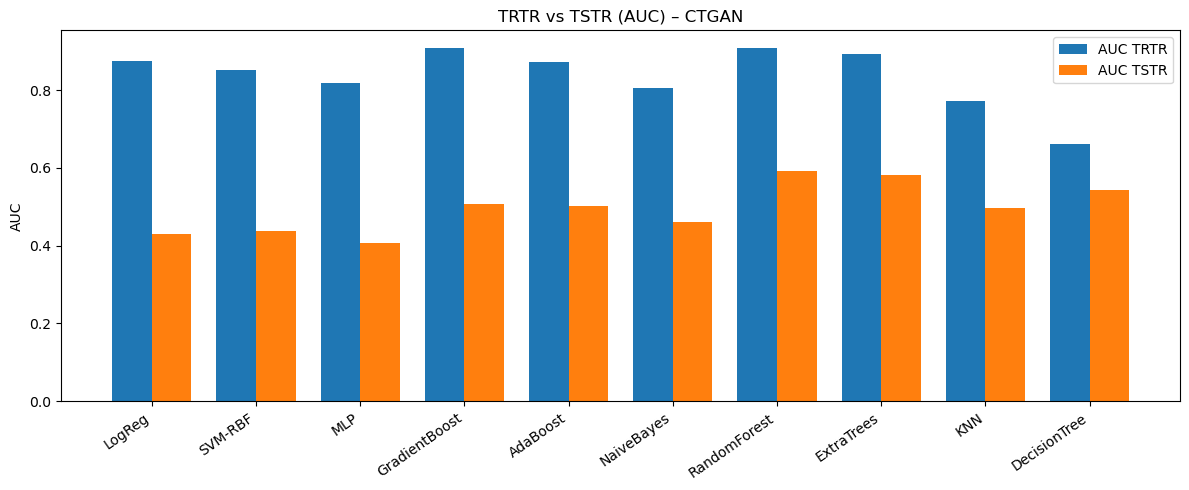

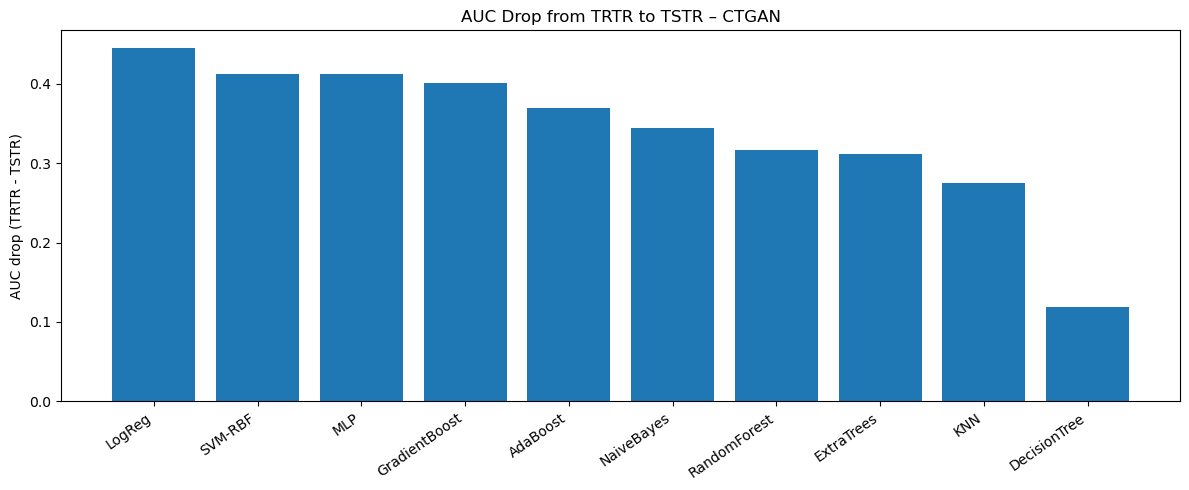


===== CopulaGAN =====


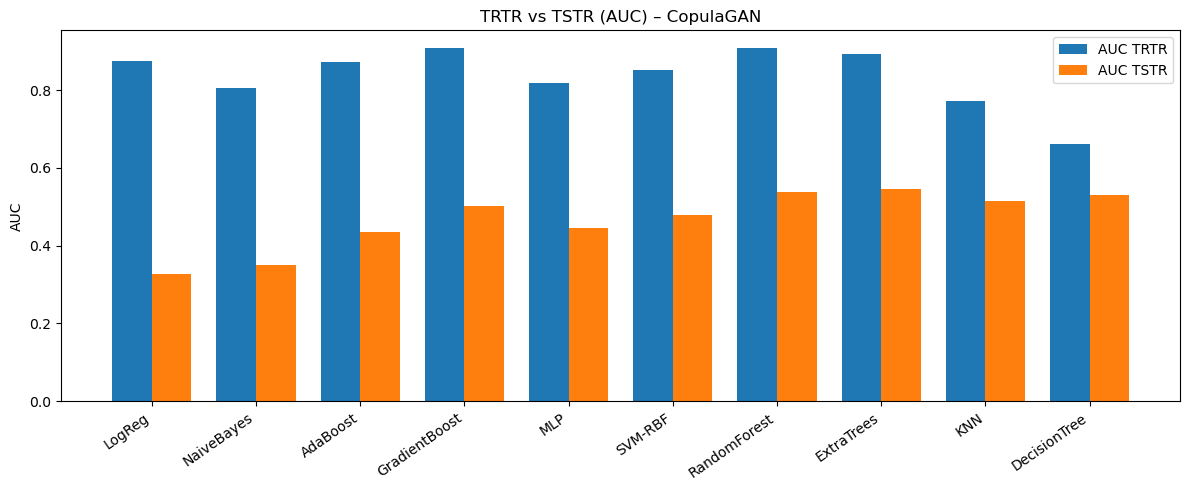

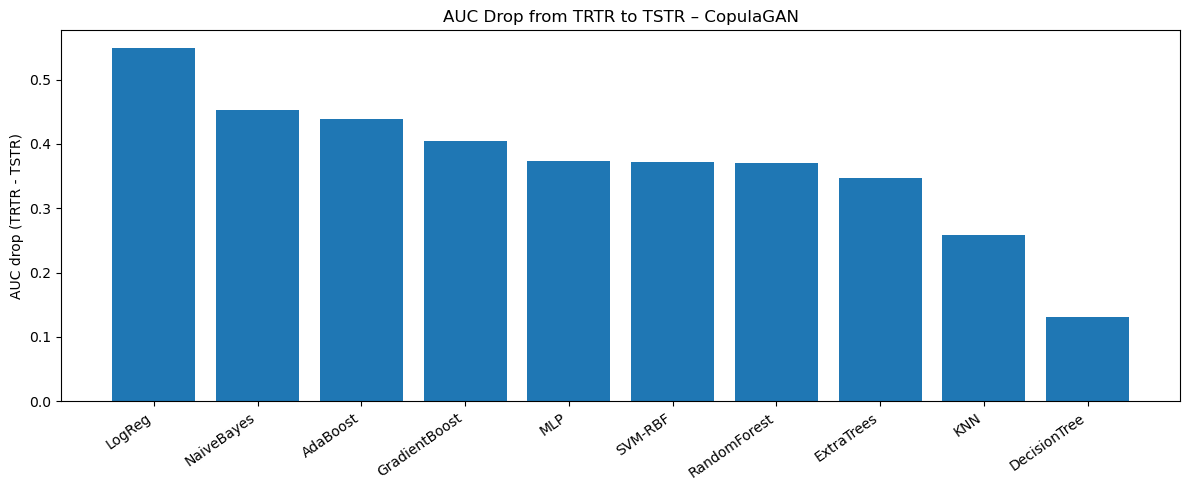


===== GaussianCopula =====


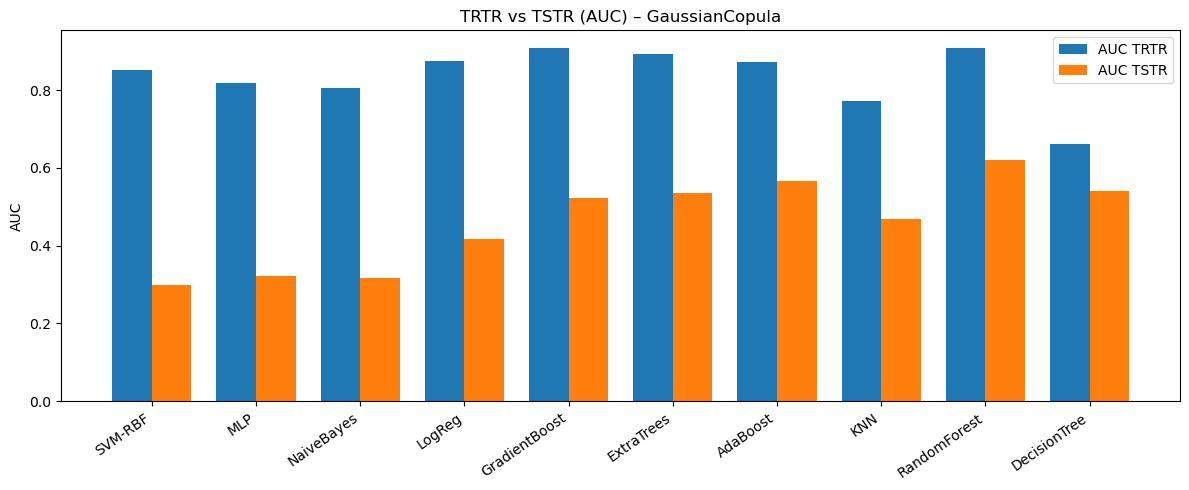

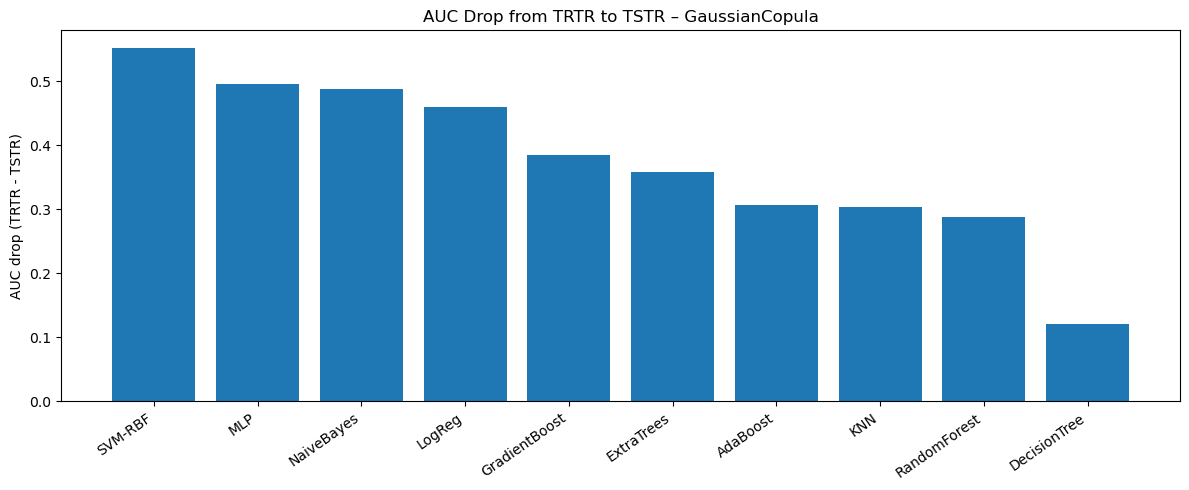


===== TVAE =====


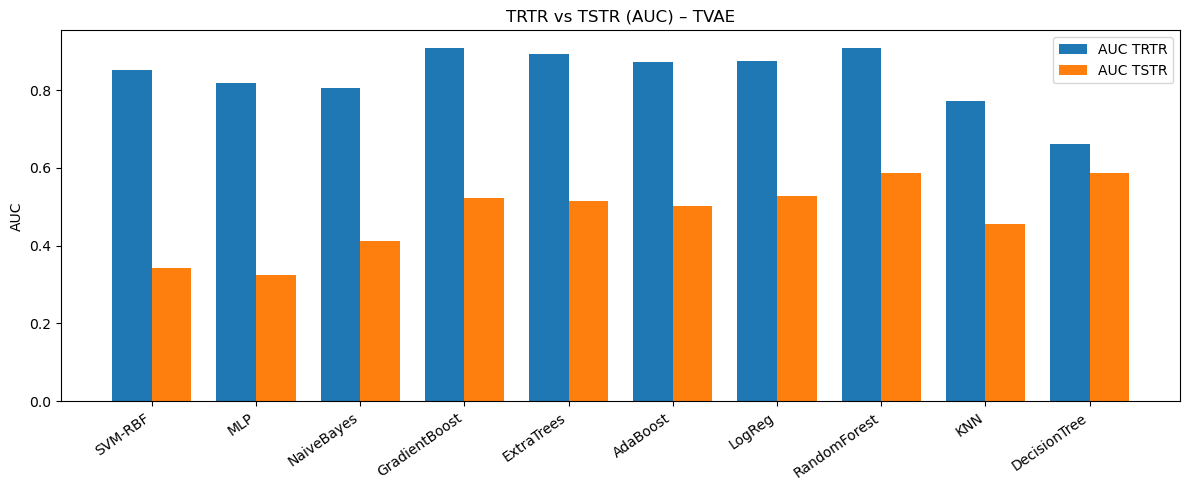

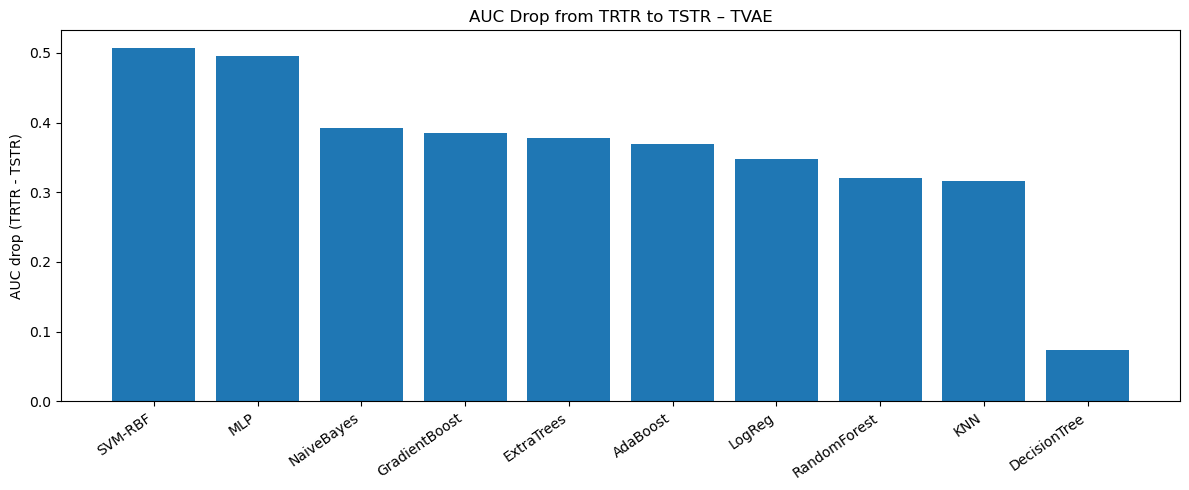

In [24]:
import numpy as np
import matplotlib.pyplot as plt

def plot_trtr_vs_tstr(trtr_results, tstr_results, metric='AUC', title_suffix=""):
    df = trtr_results[['Model', metric]].merge(
        tstr_results[['Model', metric]],
        on='Model',
        suffixes=("_TRTR", "_TSTR")
    )

    df['Drop'] = df[f"{metric}_TRTR"] - df[f"{metric}_TSTR"]
    df = df.sort_values('Drop', ascending=False)

    x = np.arange(len(df))
    w = 0.38

    plt.figure(figsize=(12, 5))
    plt.bar(x - w/2, df[f"{metric}_TRTR"], w, label=f"{metric} TRTR")
    plt.bar(x + w/2, df[f"{metric}_TSTR"], w, label=f"{metric} TSTR")
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel(metric)
    plt.title(f"TRTR vs TSTR ({metric}) {title_suffix}")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_auc_drop(comparison_df, title_suffix=""):
    df = comparison_df.sort_values("AUC_Drop", ascending=False)

    x = np.arange(len(df))
    plt.figure(figsize=(12, 5))
    plt.bar(x, df["AUC_Drop"])
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel("AUC drop (TRTR - TSTR)")
    plt.title(f"AUC Drop from TRTR to TSTR {title_suffix}")
    plt.tight_layout()
    plt.show()


# =========================================================
# APPLY TO ALL FOUR GAN MODELS
# utility_comparison must contain:
# [Model, AUC_TRTR, AUC_TSTR, AUC_Drop, GAN]
# =========================================================

for gan_name in utility_comparison["GAN"].unique():

    print(f"\n===== {gan_name} =====")

    gan_df = utility_comparison[utility_comparison["GAN"] == gan_name]

    # Reconstruct TRTR and TSTR tables (format expected by plotting functions)
    trtr_df = gan_df[["Model", "AUC_TRTR"]].rename(columns={"AUC_TRTR": "AUC"})
    tstr_df = gan_df[["Model", "AUC_TSTR"]].rename(columns={"AUC_TSTR": "AUC"})

    plot_trtr_vs_tstr(
        trtr_results=trtr_df,
        tstr_results=tstr_df,
        metric="AUC",
        title_suffix=f"– {gan_name}"
    )

    plot_auc_drop(
        comparison_df=gan_df,
        title_suffix=f"– {gan_name}"
    )


========== CTGAN ==========


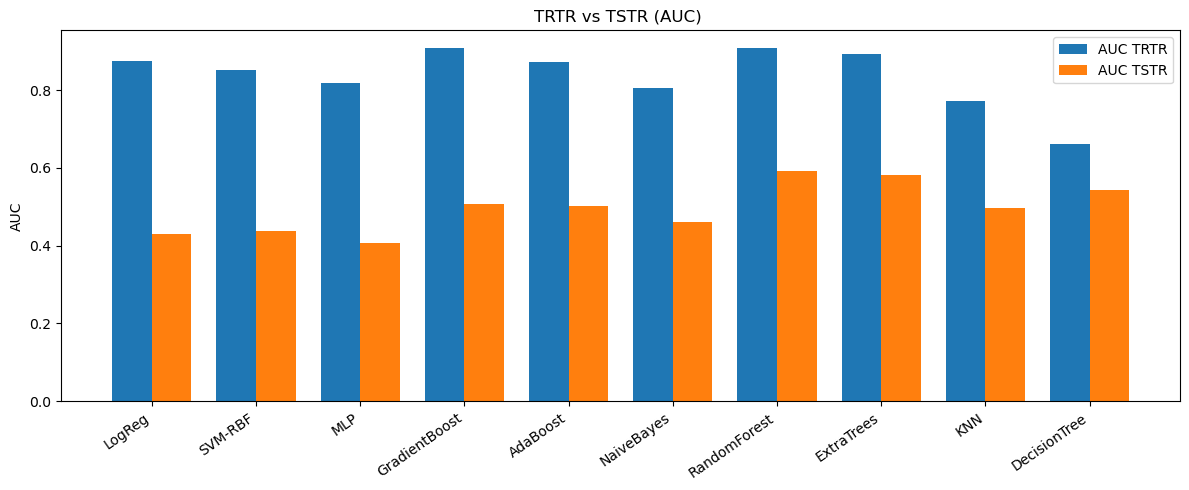

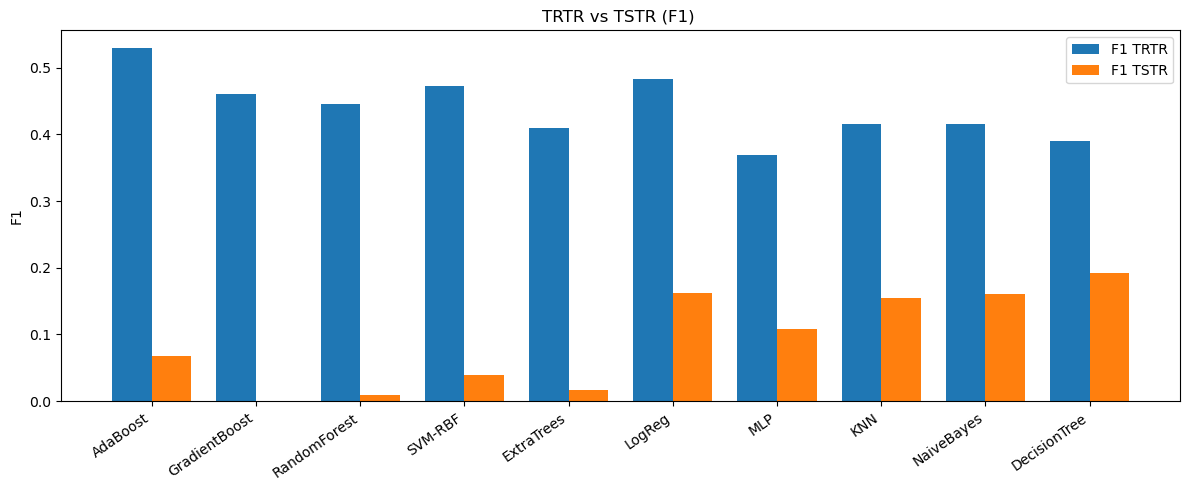

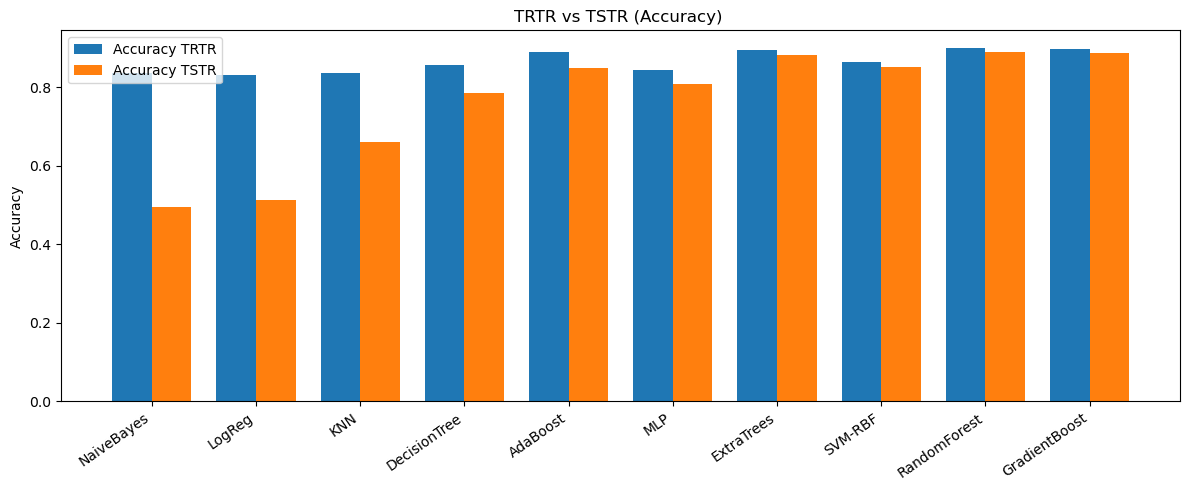

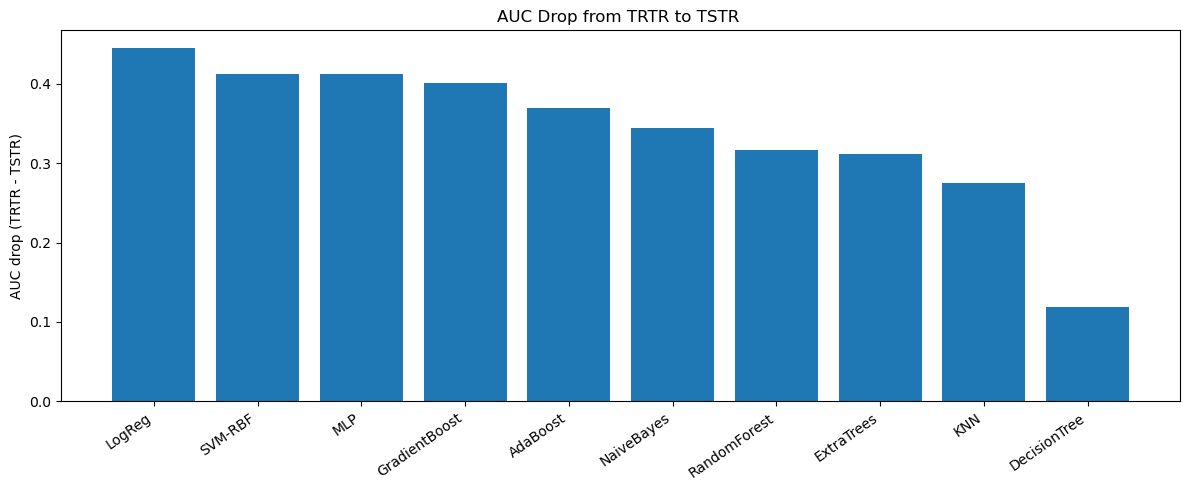


========== CopulaGAN ==========


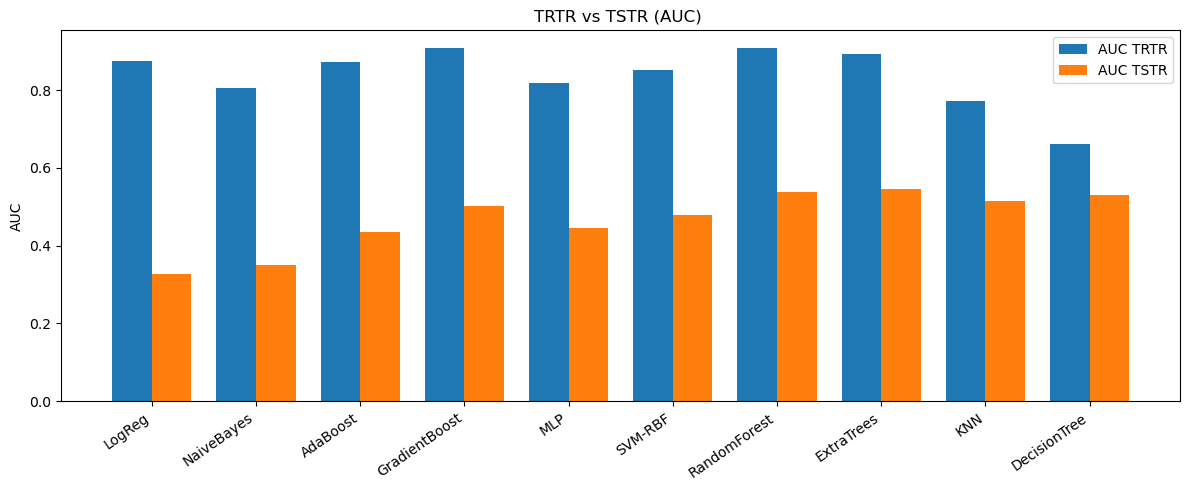

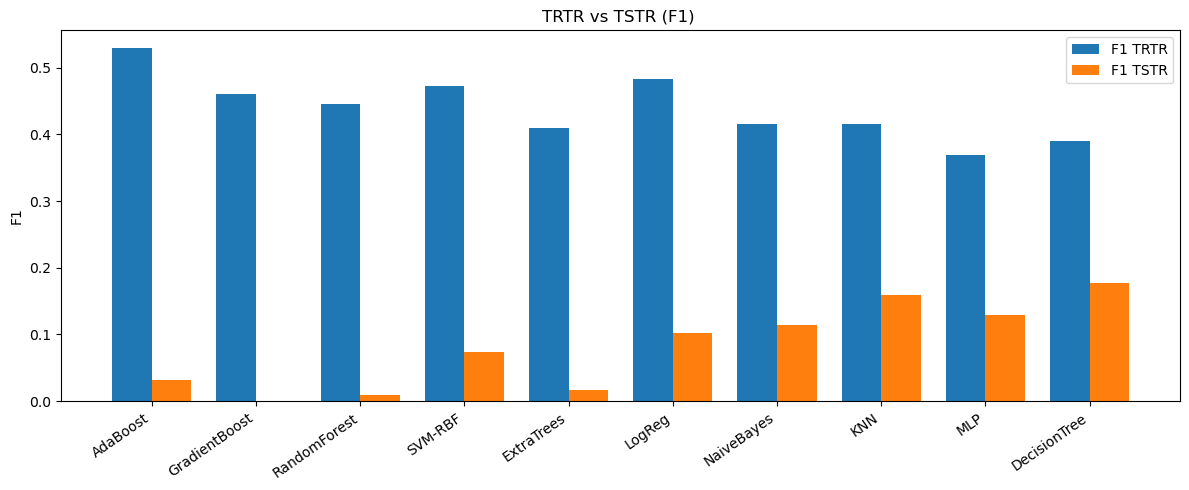

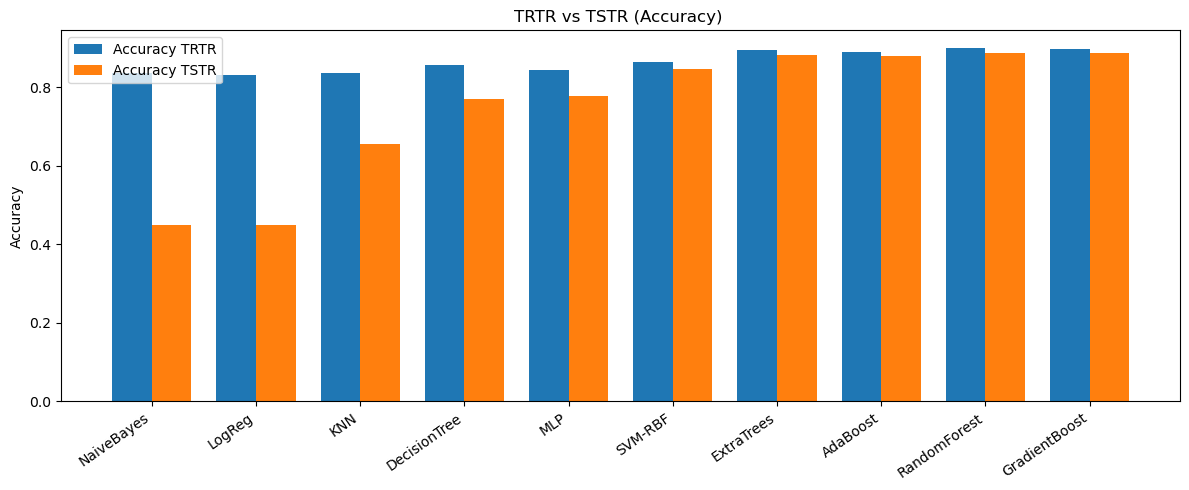

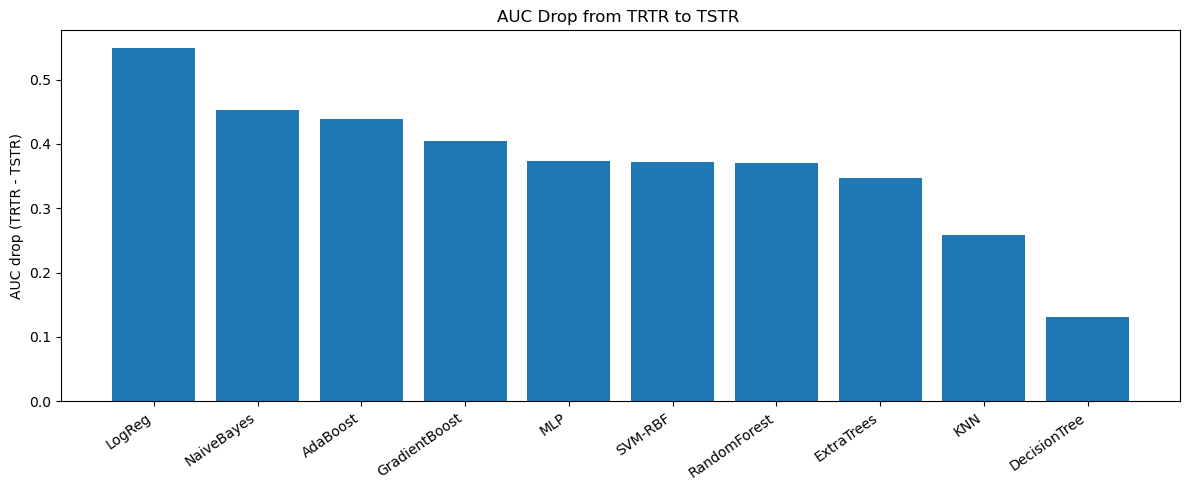


========== GaussianCopula ==========


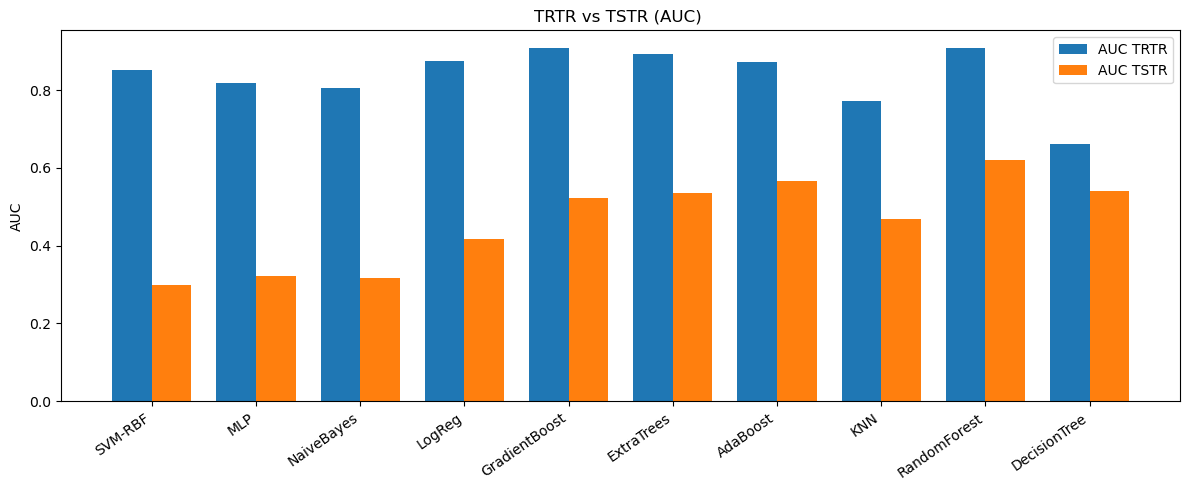

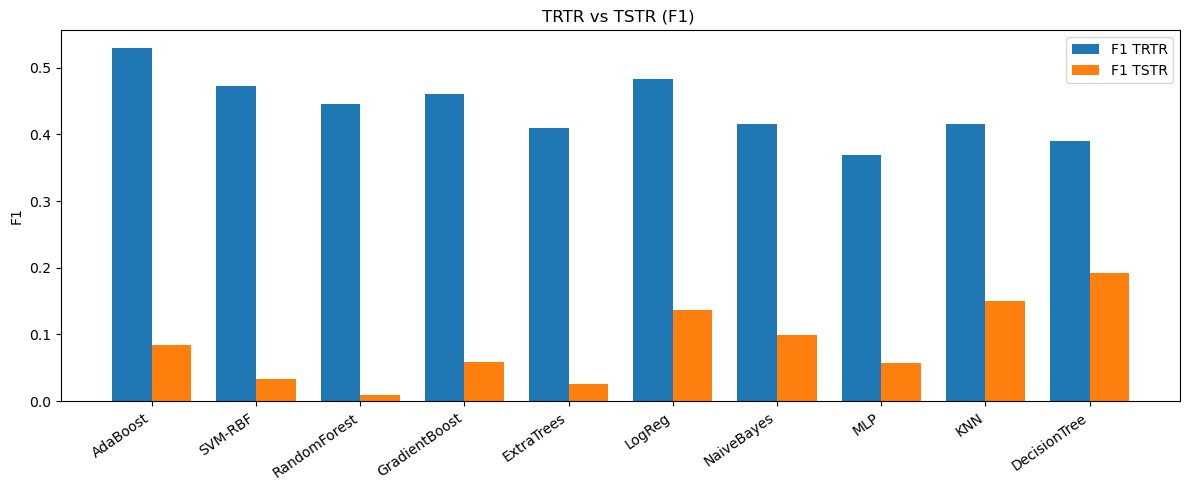

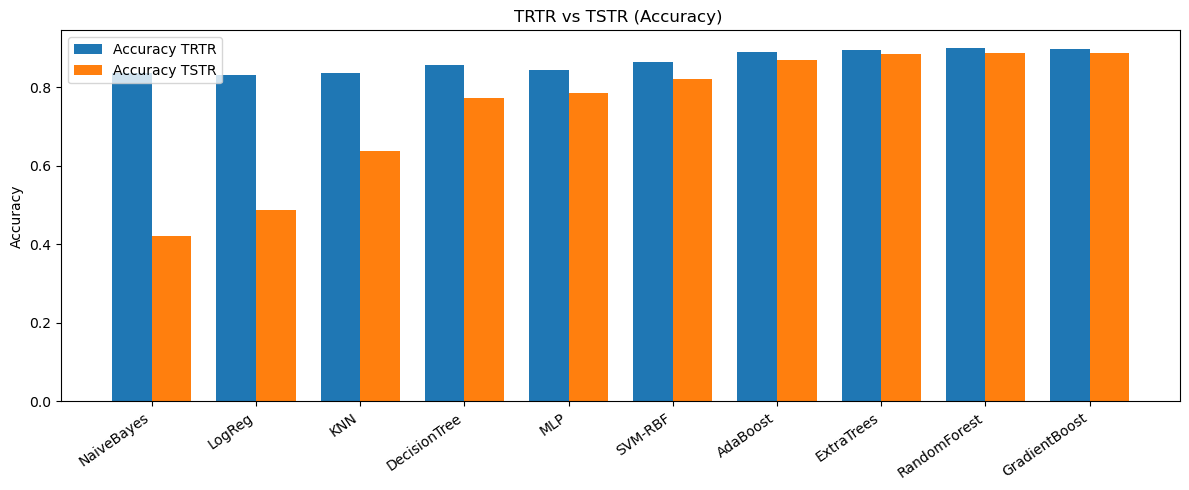

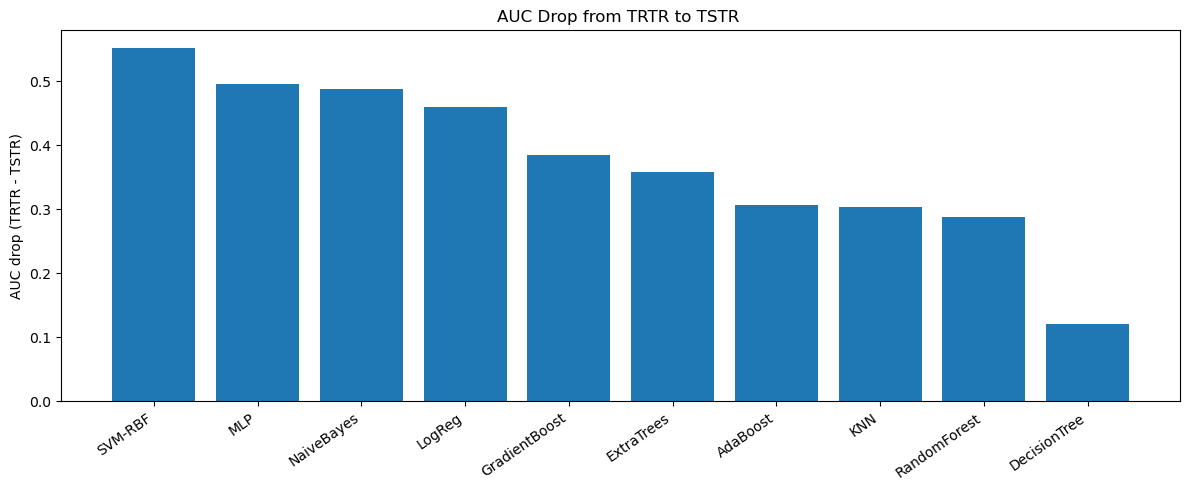


========== TVAE ==========


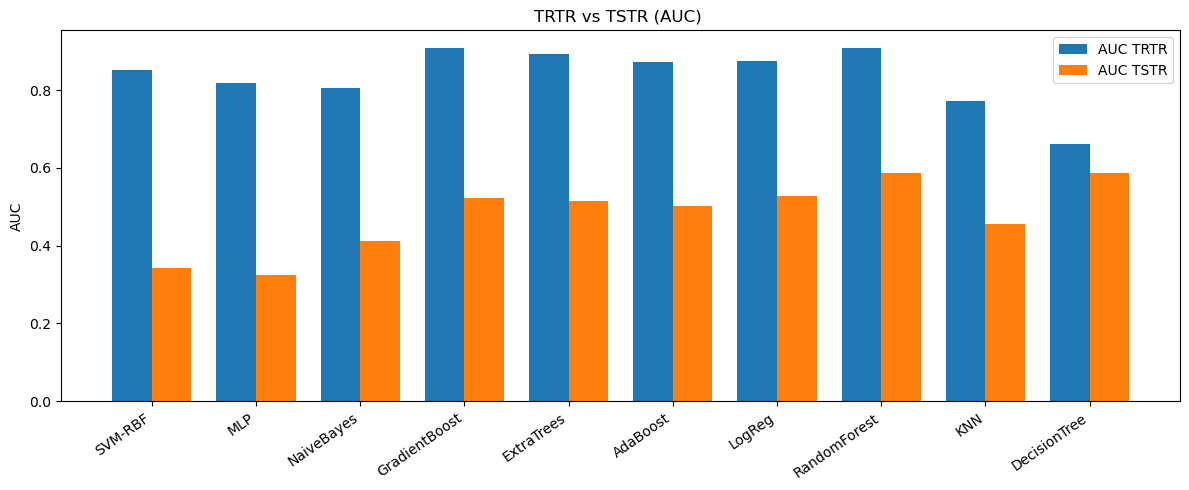

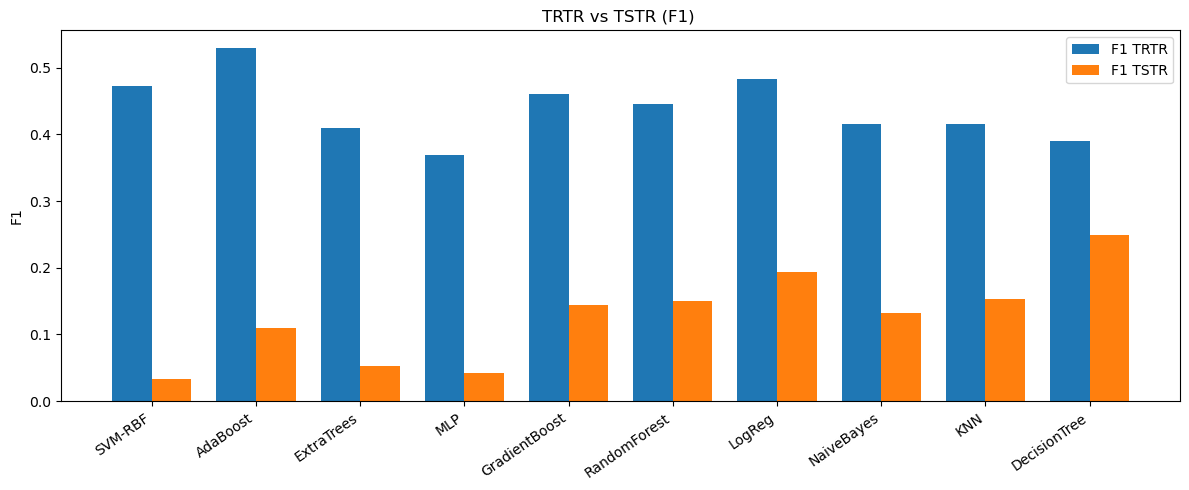

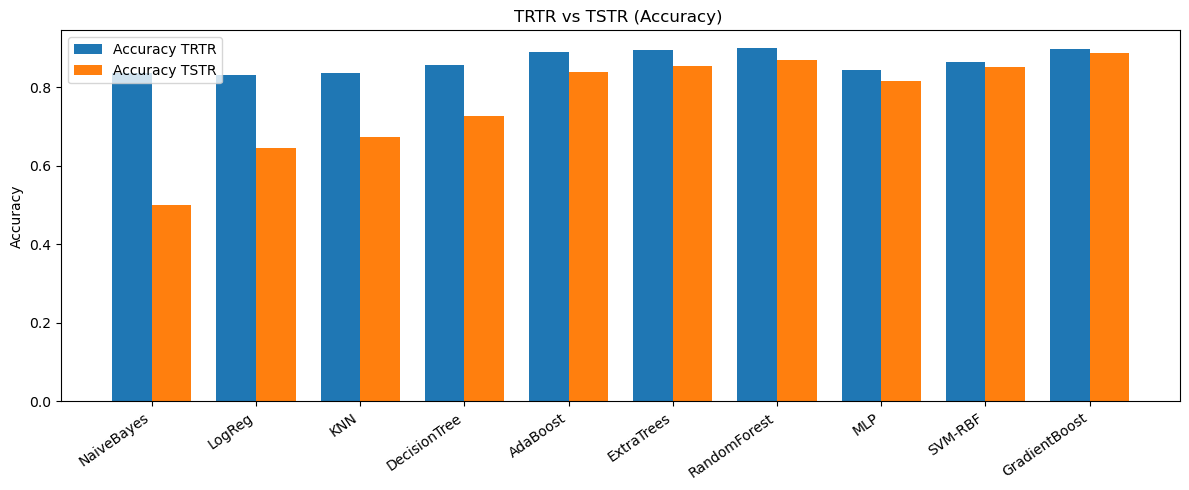

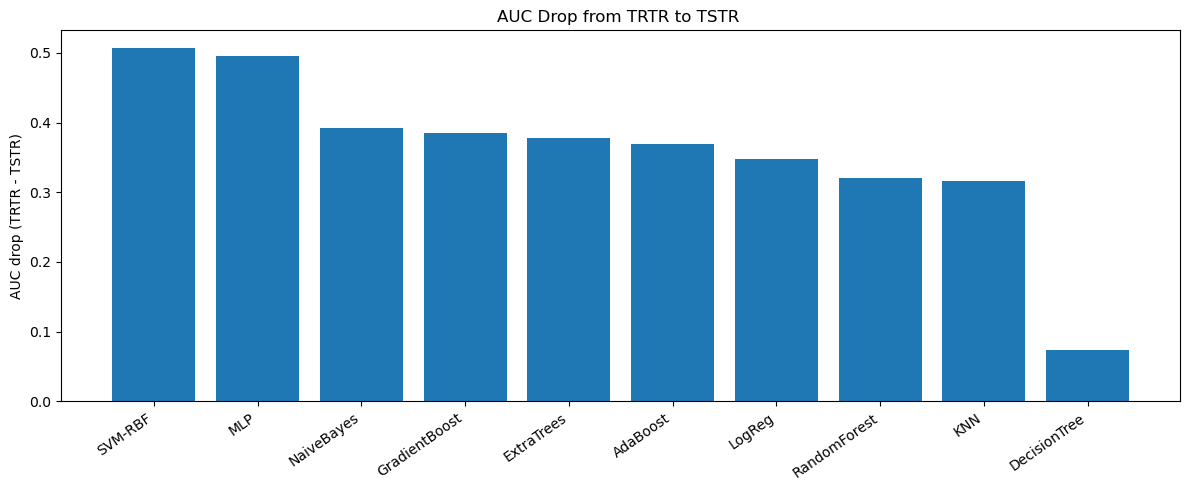

In [25]:
# =========================================================
# Apply the same plots for ALL FOUR GANs
# utility_comparison must contain:
# Model, AUC_TRTR, AUC_TSTR, F1_TRTR, F1_TSTR,
# Accuracy_TRTR, Accuracy_TSTR, AUC_Drop, GAN
# =========================================================

for gan_name in utility_comparison["GAN"].unique():

    print(f"\n========== {gan_name} ==========")

    gan_df = utility_comparison[utility_comparison["GAN"] == gan_name]

    # -------- Reconstruct TRTR / TSTR tables --------
    trtr_auc = gan_df[["Model", "AUC_TRTR"]].rename(columns={"AUC_TRTR": "AUC"})
    tstr_auc = gan_df[["Model", "AUC_TSTR"]].rename(columns={"AUC_TSTR": "AUC"})

    trtr_f1 = gan_df[["Model", "F1_TRTR"]].rename(columns={"F1_TRTR": "F1"})
    tstr_f1 = gan_df[["Model", "F1_TSTR"]].rename(columns={"F1_TSTR": "F1"})

    trtr_acc = gan_df[["Model", "Accuracy_TRTR"]].rename(columns={"Accuracy_TRTR": "Accuracy"})
    tstr_acc = gan_df[["Model", "Accuracy_TSTR"]].rename(columns={"Accuracy_TSTR": "Accuracy"})

    # -------- SAME PLOTS YOU REQUESTED --------
    plot_trtr_vs_tstr(trtr_auc, tstr_auc, metric="AUC")
    plot_trtr_vs_tstr(trtr_f1, tstr_f1, metric="F1")
    plot_trtr_vs_tstr(trtr_acc, tstr_acc, metric="Accuracy")

    plot_auc_drop(gan_df)

In [29]:
def plot_grid_line_metrics_with_gap(
    trtr_results,
    tstr_results,
    generator_name,
    ncols=5
):
    import numpy as np
    import matplotlib.pyplot as plt

    metrics = ["Accuracy", "F1", "AUC"]
    x = np.arange(len(metrics))

    trtr = trtr_results.set_index("Model")
    tstr = tstr_results.set_index("Model")

    models = [m for m in trtr.index if m in tstr.index]
    n = len(models)

    if n == 0:
        raise ValueError("No common models between TRTR and TSTR results.")

    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(4.5 * ncols, 4 * nrows),
        dpi=150,
        constrained_layout=True
    )

    axes = np.atleast_1d(axes).flatten()

    for i, model in enumerate(models):
        ax = axes[i]

        trtr_vals = trtr.loc[model, metrics].astype(float).values
        tstr_vals = tstr.loc[model, metrics].astype(float).values
        gaps = trtr_vals - tstr_vals

        ax.plot(x, trtr_vals, marker="o", linewidth=2, label="TRTR")
        ax.plot(x, tstr_vals, marker="o", linewidth=2, label="TSTR")
        ax.fill_between(x, tstr_vals, trtr_vals, alpha=0.25)

        # ---- annotate GAP values ----
        for xi, y_trtr, y_tstr, gap in zip(x, trtr_vals, tstr_vals, gaps):
            y_mid = (y_trtr + y_tstr) / 2
            ax.text(
                xi,
                y_mid,
                f"{gap:.3f}",
                ha="center",
                va="center",
                fontsize=8,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7)
            )

        ax.set_title(model, fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(metrics)
        ax.set_ylim(0, 1.05)
        ax.grid(alpha=0.3)

        if i % ncols == 0:
            ax.set_ylabel("Score")

        if i == 0:
            ax.legend(fontsize=8, loc="lower left")

    # Hide unused axes
    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        f"{generator_name} — TRTR vs TSTR per classifier\n"
        f"Numbers on curve = Generalisation gap (TRTR − TSTR)",
        fontsize=14
    )

    plt.show()


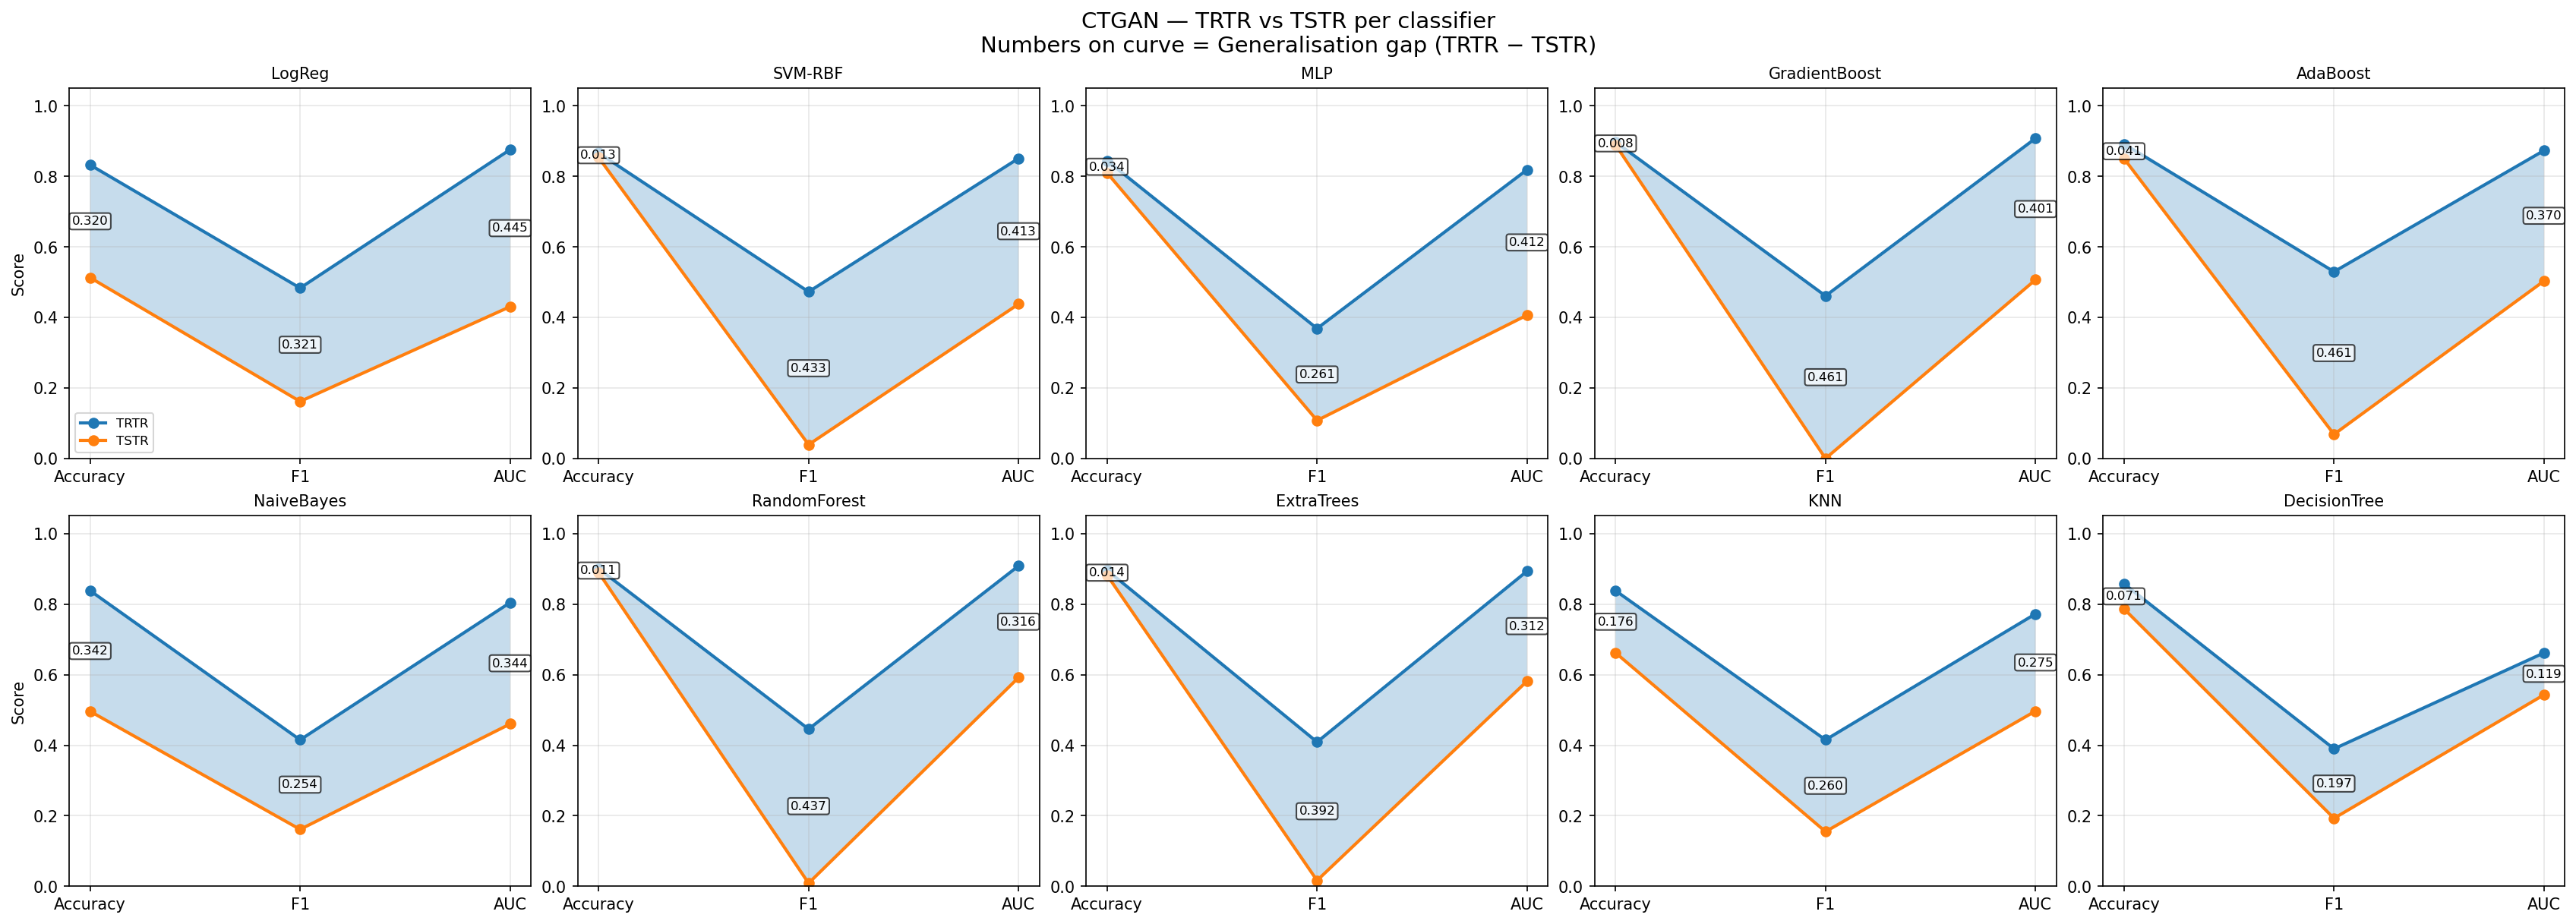

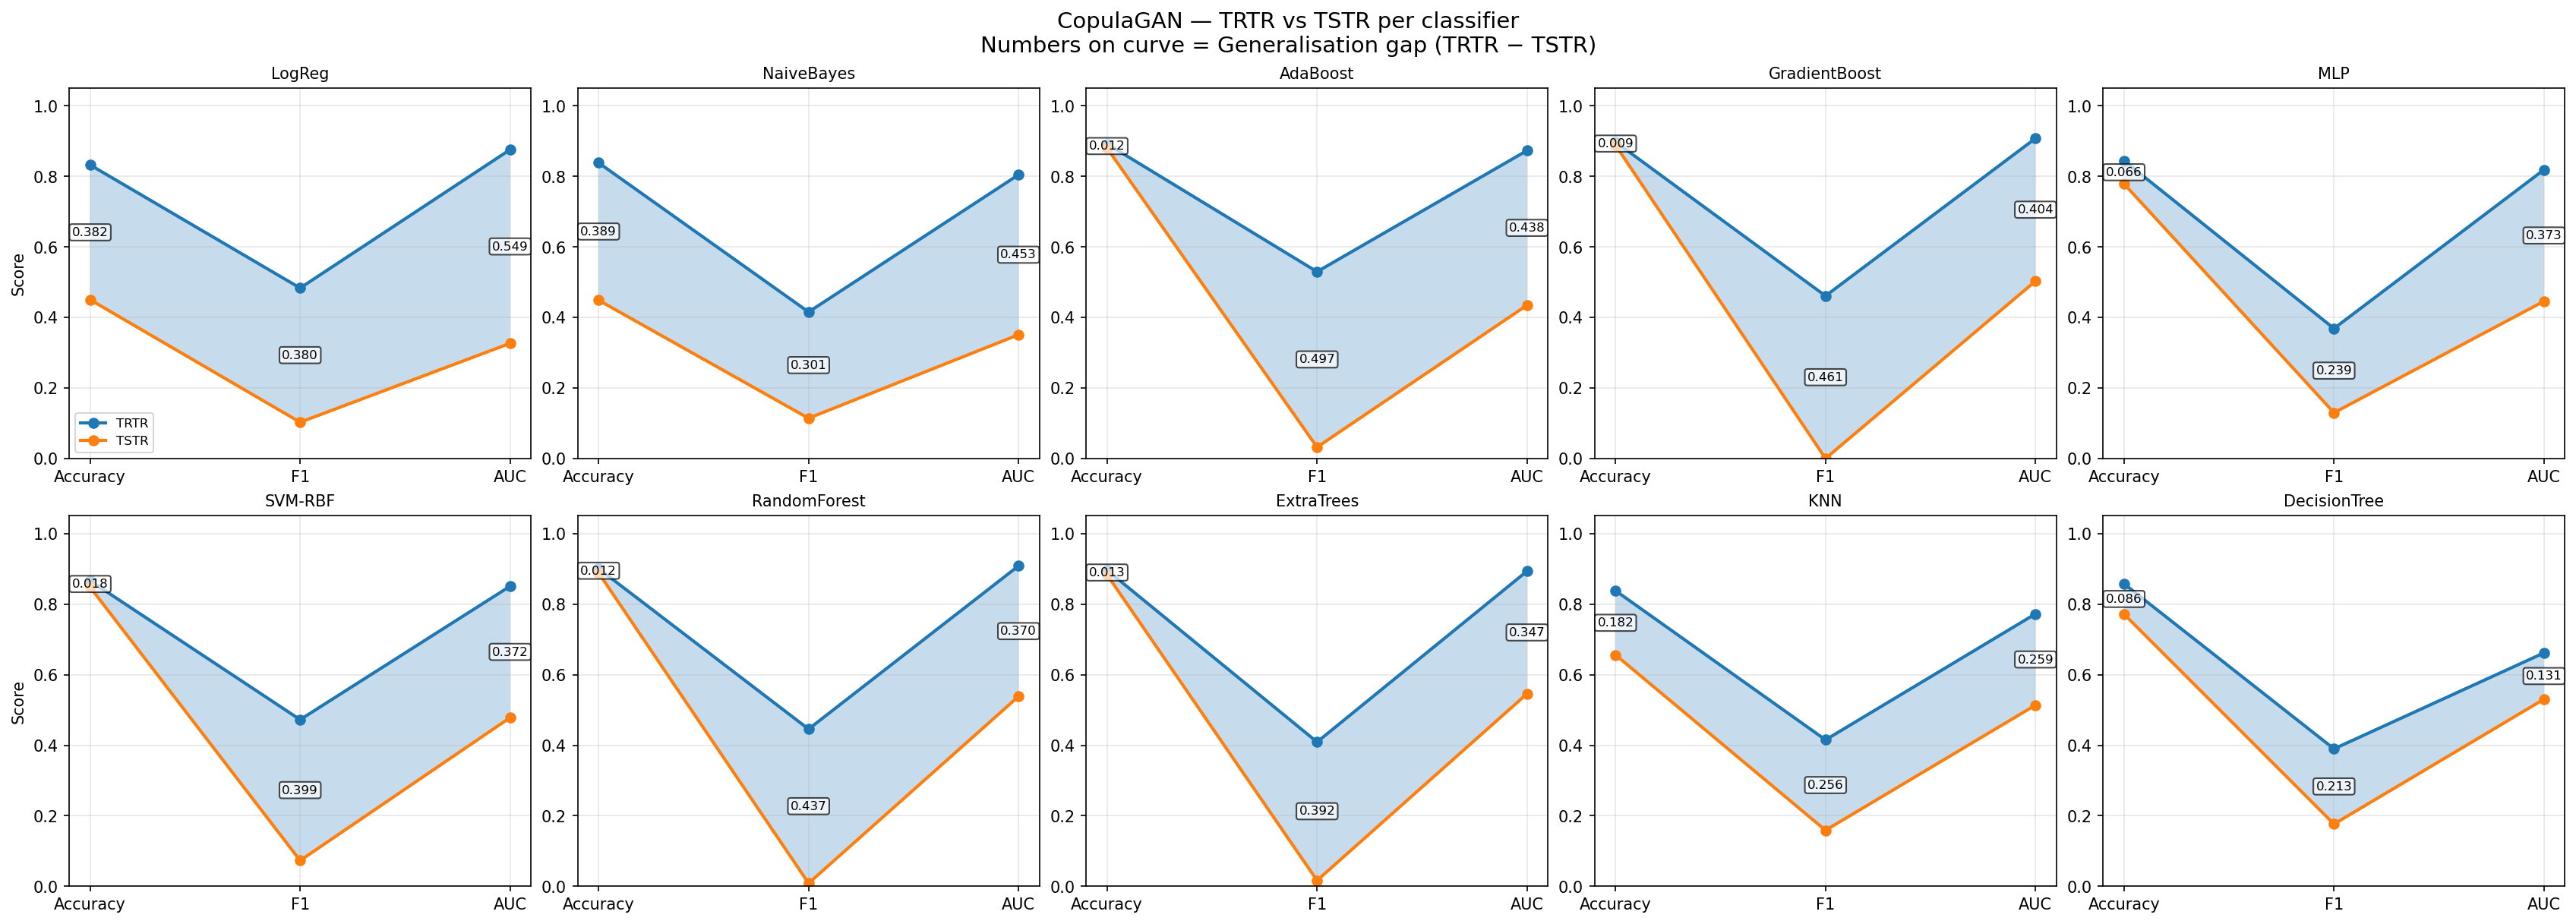

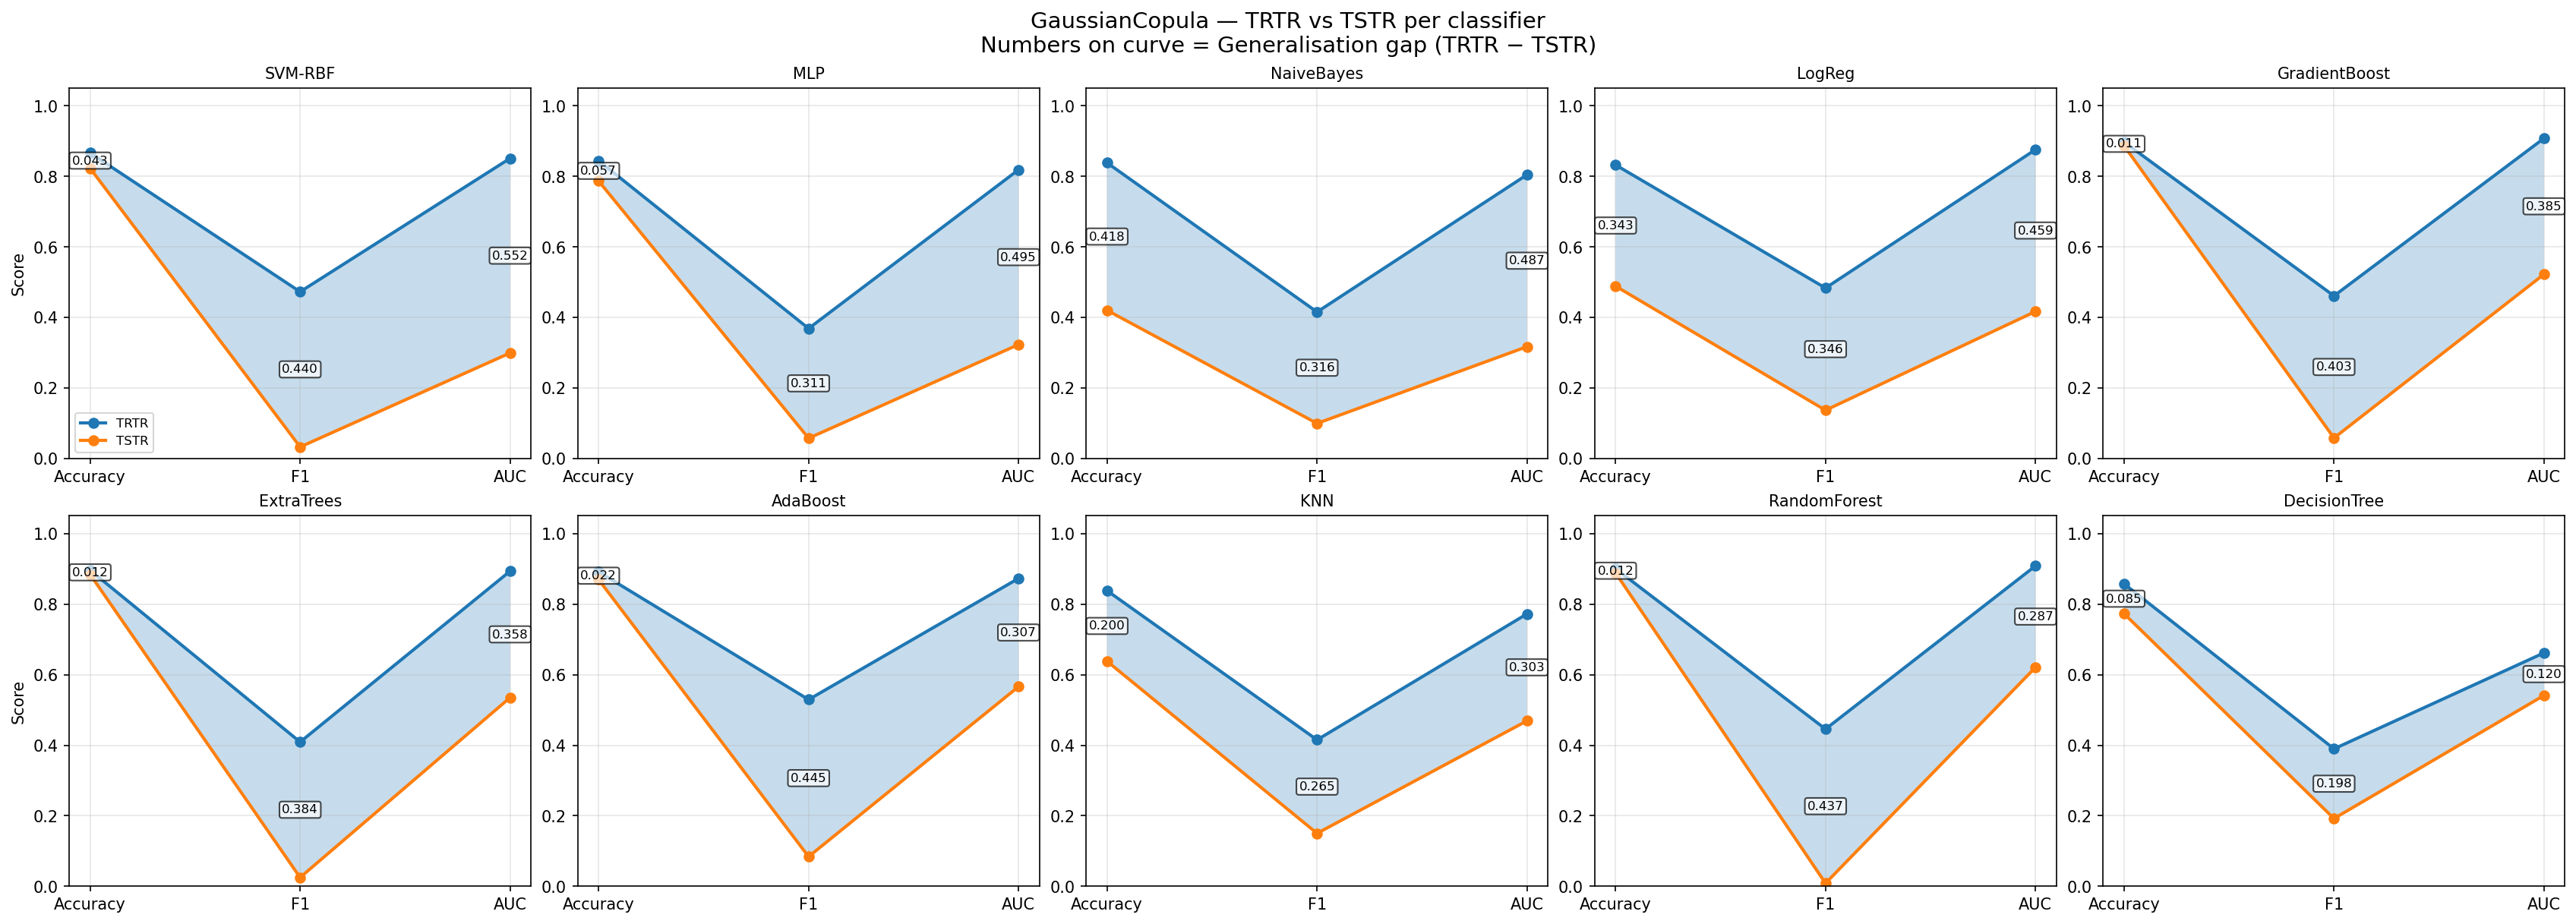

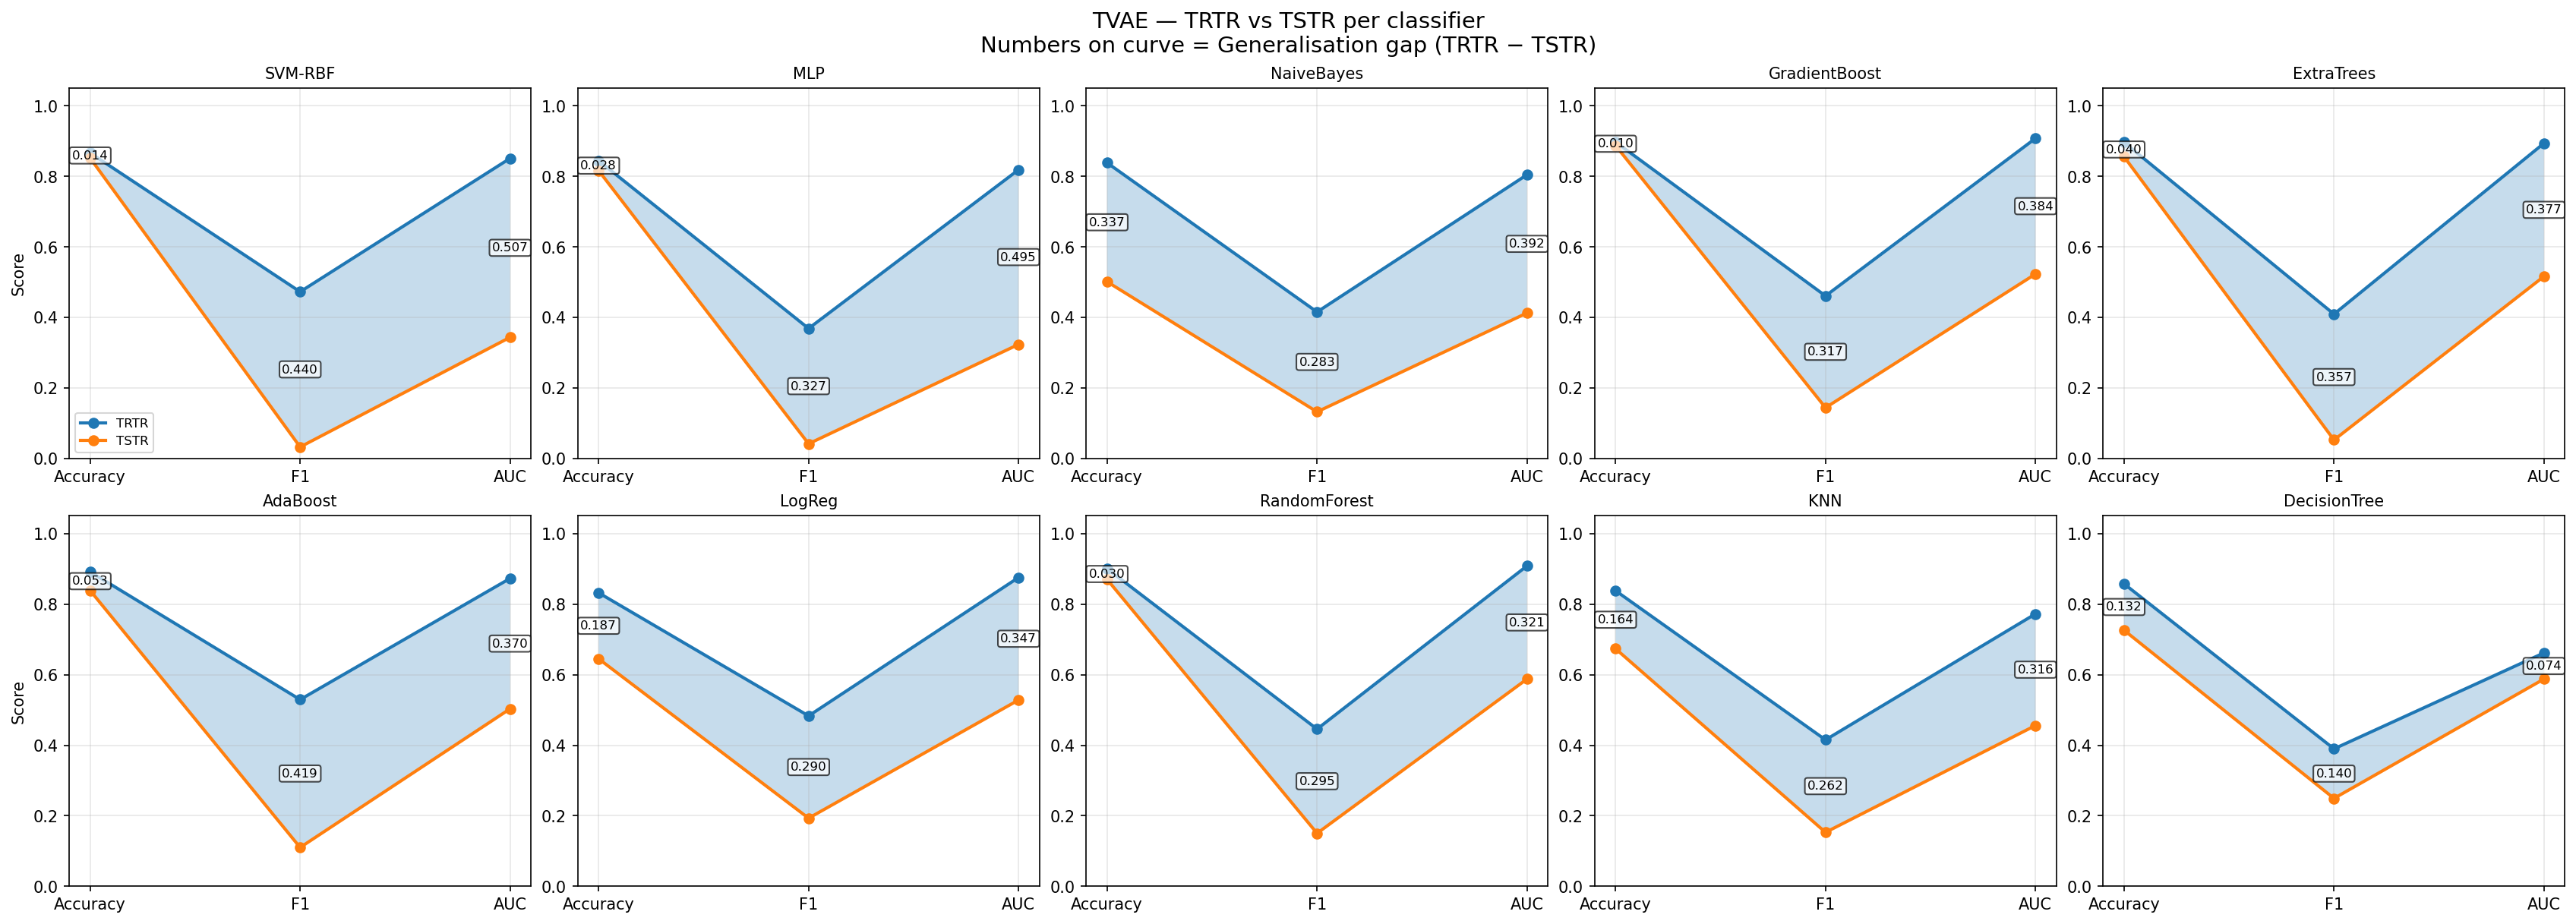

In [30]:
# Loop over GANs using utility_comparison (NOT undefined variables)
for gan_name in utility_comparison["GAN"].unique():

    gan_df = utility_comparison[utility_comparison["GAN"] == gan_name]

    # Reconstruct TRTR and TSTR result tables
    trtr_df = gan_df[[
        "Model", "Accuracy_TRTR", "F1_TRTR", "AUC_TRTR"
    ]].rename(columns={
        "Accuracy_TRTR": "Accuracy",
        "F1_TRTR": "F1",
        "AUC_TRTR": "AUC"
    })

    tstr_df = gan_df[[
        "Model", "Accuracy_TSTR", "F1_TSTR", "AUC_TSTR"
    ]].rename(columns={
        "Accuracy_TSTR": "Accuracy",
        "F1_TSTR": "F1",
        "AUC_TSTR": "AUC"
    })

    # Plot with gap values on curves
    plot_grid_line_metrics_with_gap(
        trtr_df,
        tstr_df,
        generator_name=gan_name,
        ncols=5
    )


# Hungarian assesment 

In [31]:
import numpy as np
from numpy.linalg import norm
from sklearn.preprocessing import StandardScaler
import pandas as pd

# ------------------------------------
# Use FEATURES ONLY (drop y)
# ------------------------------------
X_real = data.drop(columns=["y"])

# ------------------------------------
# Normalize rows (cosine similarity prep)
# ------------------------------------
def normalize_rows(X):
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

# ------------------------------------
# Prepare real matrix
# ------------------------------------
real_matrix = normalize_rows(X_real.to_numpy(float))

cosine_results = []

# ------------------------------------
# Compute cosine similarity for each GAN
# ------------------------------------
for gan_name, synth_df in synthetic_data.items():

    # Ensure same columns & order
    synth_df = synth_df[X_real.columns]

    synth_matrix = normalize_rows(synth_df.to_numpy(float))

    # Ensure equal sample size
    n = min(len(real_matrix), len(synth_matrix))
    real_n = real_matrix[:n]
    synth_n = synth_matrix[:n]

    # Cosine similarity = dot product after normalization
    cosine_sim = np.sum(real_n * synth_n, axis=1)

    cosine_results.append({
        "GAN": gan_name,
        "Average_Cosine": cosine_sim.mean(),
        "Max_Cosine": cosine_sim.max()
    })

# ------------------------------------
# Results table
# ------------------------------------
cosine_results_df = pd.DataFrame(cosine_results)
cosine_results_df

,GAN,Average_Cosine,Max_Cosine
0,CTGAN,0.881614,0.999992
1,CopulaGAN,0.867937,0.999990
2,GaussianCopula,0.931046,0.999990
3,TVAE,0.924308,0.999995


In [32]:
cosine_dfs = {}

N = 10000  # number of rows/columns to use

for model_name, synth_df in synthetic_data.items():
    print(f"Building cosine similarity DataFrame for {model_name}......")

    # Normalize synthetic matrix
    synth_matrix = normalize_rows(synth_df.to_numpy(float))

    # Compute cosine similarity matrix
    cosine_matrix = real_matrix @ synth_matrix.T

    # Build DataFrame (first 10000 × 10000 block)
    cosine_df = pd.DataFrame(
        cosine_matrix[:N, :N],
        index=[f"R{i+1}" for i in range(N)],
        columns=[f"S{j+1}" for j in range(N)]
    )

    # Save in dictionary
    cosine_dfs[model_name] = cosine_df

    # 🔹 PRINT ONLY TOP 10 ROWS (to avoid flooding output)
    print(cosine_df.head(10), "\n")

Building cosine similarity DataFrame for CTGAN......
           S1        S2        S3        S4        S5        S6        S7  \
R1   0.993431  0.999969  0.992569  0.993839  0.992838  0.941676  0.303429   
R2   0.995811  0.999492  0.995296  0.996263  0.995277  0.933298  0.278449   
R3   0.735106  0.808894  0.730597  0.738040  0.731747  0.958937  0.763515   
R4   0.999849  0.994241  0.999834  0.999926  0.999727  0.901669  0.207036   
R5   0.970363  0.991843  0.968582  0.971269  0.969163  0.977159  0.416468   
R6   0.989739  0.999321  0.989040  0.990518  0.988908  0.950377  0.319672   
R7   0.951014  0.980195  0.949323  0.952657  0.949314  0.989367  0.461205   
R8   0.999706  0.994734  0.999732  0.999879  0.999514  0.904137  0.209997   
R9   0.916182  0.956488  0.913612  0.917983  0.914150  0.998945  0.544780   
R10  0.938045  0.971787  0.936046  0.939791  0.936205  0.994435  0.494632   

           S8        S9       S10  ...     S9991     S9992     S9993  \
R1   0.982548  0.280374  0.

In [33]:
import numpy as np
import pandas as pd
from numpy.linalg import norm
from scipy.optimize import linear_sum_assignment

# -------------------------------------------------
# Feature-only real data (drop target)
# -------------------------------------------------
real_df = data.drop(columns=["y"])

# -------------------------------------------------
# Cosine similarity helpers
# -------------------------------------------------
def normalize_rows(X: np.ndarray) -> np.ndarray:
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

def cosine_similarity_matrix(
    real_df: pd.DataFrame,
    synth_df: pd.DataFrame,
    num_cols=None
) -> np.ndarray:

    if num_cols is None:
        num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

    R = real_df[num_cols].to_numpy(dtype=float)
    S = synth_df[num_cols].to_numpy(dtype=float)

    R_norm = normalize_rows(R)
    S_norm = normalize_rows(S)

    return R_norm @ S_norm.T


# -------------------------------------------------
# Hungarian-based optimal matching
# -------------------------------------------------
def hungarian_match(
    real_df: pd.DataFrame,
    synth_df: pd.DataFrame,
    num_cols=None
):
    cos_sim = cosine_similarity_matrix(real_df, synth_df, num_cols)
    n_real, n_synth = cos_sim.shape

    # Maximize similarity → minimize cost
    if n_real <= n_synth:
        cost = 1.0 - cos_sim
        row_ind, col_ind = linear_sum_assignment(cost)
        selected = cos_sim[row_ind, col_ind]
    else:
        cost = 1.0 - cos_sim.T
        col_ind, row_ind = linear_sum_assignment(cost)
        selected = cos_sim[row_ind, col_ind]

    return row_ind, col_ind, selected, float(selected.mean()), cos_sim


# -------------------------------------------------
# Run Hungarian matching for ALL FOUR GANs
# -------------------------------------------------
results = {}

for gan_name, synth_df in synthetic_data.items():

    print(f"\n==============================")
    print(f"{gan_name}: Hungarian Matching (Cosine Similarity)")
    print(f"==============================")

    # Ensure identical column order
    synth_df = synth_df[real_df.columns]

    row_ind, col_ind, sims, avg_sim, cos_matrix = hungarian_match(
        real_df,
        synth_df,
        num_cols=None
    )

    results[gan_name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "similarities": sims,
        "avg_similarity": avg_sim,
        "cos_matrix": cos_matrix
    }

    print(f"Average cosine similarity (Hungarian): {avg_sim:.4f}\n")

    # Show first 10 matched pairs
    for k in range(min(10, len(row_ind))):
        r = row_ind[k]
        s = col_ind[k]
        print(f"R{r+1} ↔ S{s+1}   cosine similarity = {sims[k]:.4f}")


CTGAN: Hungarian Matching (Cosine Similarity)
Average cosine similarity (Hungarian): 0.9832

R1 ↔ S6600   cosine similarity = 1.0000
R2 ↔ S1595   cosine similarity = 1.0000
R3 ↔ S1562   cosine similarity = 0.7782
R4 ↔ S5775   cosine similarity = 0.9999
R5 ↔ S5723   cosine similarity = 0.9999
R6 ↔ S8347   cosine similarity = 1.0000
R7 ↔ S6265   cosine similarity = 0.9990
R8 ↔ S3474   cosine similarity = 1.0000
R9 ↔ S2072   cosine similarity = 0.9873
R10 ↔ S643   cosine similarity = 0.9956

CopulaGAN: Hungarian Matching (Cosine Similarity)
Average cosine similarity (Hungarian): 0.9723

R1 ↔ S5679   cosine similarity = 0.9975
R2 ↔ S4473   cosine similarity = 0.9983
R3 ↔ S1226   cosine similarity = 0.7591
R4 ↔ S3183   cosine similarity = 0.9987
R5 ↔ S2314   cosine similarity = 0.9913
R6 ↔ S7873   cosine similarity = 0.9962
R7 ↔ S1510   cosine similarity = 0.9779
R8 ↔ S5733   cosine similarity = 0.9986
R9 ↔ S9116   cosine similarity = 0.9436
R10 ↔ S3040   cosine similarity = 0.9676

Gaussi

In [35]:
# -----------------------------
# Use FEATURES ONLY (drop y)
# -----------------------------
X_real = data.drop(columns=["y"])

# -----------------------------
# Initialize models
# -----------------------------
gc_model    = GaussianCopulaSynthesizer(metadata=metadata)
ctgan_model = CTGANSynthesizer(metadata=metadata)
cop_model   = CopulaGANSynthesizer(metadata=metadata)
tvae_model  = TVAESynthesizer(metadata=metadata)

# -----------------------------
# Fit models (FEATURES ONLY)
# -----------------------------
gc_model.fit(X_real)
ctgan_model.fit(X_real)
cop_model.fit(X_real)
tvae_model.fit(X_real)

# -----------------------------
# Sample 20,000 rows
# -----------------------------
N_SYNTH = 20000

synthetic_data_gaussian_copula = gc_model.sample(num_rows=N_SYNTH)
synthetic_data_ctgan           = ctgan_model.sample(num_rows=N_SYNTH)
synthetic_data_copulagan       = cop_model.sample(num_rows=N_SYNTH)
synthetic_data_tvae            = tvae_model.sample(num_rows=N_SYNTH)

KeyboardInterrupt: 

In [ ]:
from sklearn.cluster import KMeans
import numpy as np
from numpy.linalg import norm
import pandas as pd

def normalize_rows(X: np.ndarray) -> np.ndarray:
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

def cluster_synthetic_and_match(
    real_df: pd.DataFrame,
    synth_df: pd.DataFrame,
    num_cols,
    n_clusters: int = 1000,
    random_state: int = 42,
    max_synth_samples: int = 5000
):
    """
    Cluster synthetic data (numeric features only) and match each real sample
    to the closest synthetic centroid using cosine similarity.

    Returns:
    - centroid_assignments: index of best centroid per real sample
    - centroid_similarities: cosine similarity to best centroid
    - centroids: centroid vectors
    - cos_sim_matrix: real × centroid cosine similarity
    - kmeans_labels: cluster labels for synthetic samples used in clustering
    """

    # -----------------------------
    # Extract numeric features
    # -----------------------------
    R = real_df[num_cols].to_numpy(dtype=float)
    S = synth_df[num_cols].to_numpy(dtype=float)

    n_real = R.shape[0]

    # -----------------------------
    # Subsample synthetic data (important for 20k+)
    # -----------------------------
    if S.shape[0] > max_synth_samples:
        rng = np.random.default_rng(random_state)
        idx = rng.choice(S.shape[0], max_synth_samples, replace=False)
        S = S[idx]

    # -----------------------------
    # Normalize synthetic data
    # -----------------------------
    S_norm = normalize_rows(S)

    # -----------------------------
    # KMeans clustering
    # -----------------------------
    n_clusters = min(n_clusters, S_norm.shape[0])

    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=random_state,
        n_init=10
    )
    kmeans.fit(S_norm)

    centroids = kmeans.cluster_centers_
    centroids_norm = normalize_rows(centroids)

    # -----------------------------
    # Normalize real data
    # -----------------------------
    R_norm = normalize_rows(R)

    # -----------------------------
    # Cosine similarity (real ↔ centroids)
    # -----------------------------
    cos_sim_matrix = R_norm @ centroids_norm.T

    centroid_assignments = np.argmax(cos_sim_matrix, axis=1)
    centroid_similarities = cos_sim_matrix[
        np.arange(n_real), centroid_assignments
    ]

    return {
        "centroid_assignments": centroid_assignments,
        "centroid_similarities": centroid_similarities,
        "centroids": centroids,
        "cos_sim_matrix": cos_sim_matrix,
        "kmeans_labels": kmeans.labels_
    }

In [ ]:
real_df = data

# Use ALL numeric features
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

synthetic_tables = {
    "GaussianCopula": synthetic_data_gaussian_copula,
    "CTGAN":          synthetic_data_ctgan,
    "CopulaGAN":      synthetic_data_copulagan,
    "TVAE":           synthetic_data_tvae,
}

cluster_results = {}

TOP_K = 10  # only show top 10 matches

for model_name, synth_df in synthetic_tables.items():
    print("\n===================================================")
    print(f"{model_name}: clustering synthetic and matching to real (TOP {TOP_K})")
    print("===================================================\n")

    res = cluster_synthetic_and_match(
        real_df=real_df,
        synth_df=synth_df,
        num_cols=num_cols,
        n_clusters=min(len(real_df), 1000),  # safe & scalable
        random_state=42
    )

    centroid_assignments = res["centroid_assignments"]
    centroid_sims = res["centroid_similarities"]
    synth_cluster_labels = res["kmeans_labels"]

    cluster_results[model_name] = res

    # -------- TOP-10 matches --------
    print("Top-10 Real → Centroid matches:\n")
    for i in range(min(TOP_K, len(centroid_assignments))):
        print(
            f"R{i+1} → Centroid {centroid_assignments[i]} "
            f"(cosine similarity = {centroid_sims[i]:.4f})"
        )

    # -------- Summary stats --------
    print(f"\nAverage centroid similarity: {centroid_sims.mean():.4f}")
    print(f"Minimum centroid similarity: {centroid_sims.min():.4f}")

    # -------- Cluster size summary (TOP-10 clusters only) --------
    print("\nTop-10 cluster sizes:")
    cluster_counts = np.bincount(synth_cluster_labels)
    top_clusters = np.argsort(cluster_counts)[-TOP_K:][::-1]

    for k in top_clusters:
        print(f"Cluster {k}: {cluster_counts[k]} synthetic samples")

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Settings
# -----------------------------
N_REAL = 1000
N_SYNTH = 1000
N_CLUSTERS = 100
RANDOM_STATE = 42

# Numeric features only
real_df = data
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

synthetic_tables = {
    "GaussianCopula": synthetic_data_gaussian_copula,
    "CTGAN":          synthetic_data_ctgan,
    "CopulaGAN":      synthetic_data_copulagan,
    "TVAE":           synthetic_data_tvae,
}

for model_name, synth_df in synthetic_tables.items():
    print(f"\n=== PCA (1000 real / 1000 synth / 100 clusters): {model_name} ===")

    # ---- Subsample real & synthetic ----
    real_sub = real_df.sample(N_REAL, random_state=RANDOM_STATE)
    synth_sub = synth_df.sample(N_SYNTH, random_state=RANDOM_STATE)

    # ---- Cluster synthetic ----
    res = cluster_synthetic_and_match(
        real_df=real_sub,
        synth_df=synth_sub,
        num_cols=num_cols,
        n_clusters=N_CLUSTERS,
        random_state=RANDOM_STATE
    )

    # ---- Normalize ----
    X_real = normalize_rows(real_sub[num_cols].to_numpy(float))
    X_synth = normalize_rows(synth_sub[num_cols].to_numpy(float))
    X_centroids = normalize_rows(res["centroids"])

    # ---- PCA fit on real ----
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    pca.fit(X_real)

    X_real_2d = pca.transform(X_real)
    X_synth_2d = pca.transform(X_synth)
    X_centroids_2d = pca.transform(X_centroids)

    # ---- Plot ----
    plt.figure(figsize=(8, 5))

    plt.hexbin(
        X_synth_2d[:, 0], X_synth_2d[:, 1],
        gridsize=40, mincnt=1, alpha=0.7
    )

    plt.scatter(
        X_real_2d[:, 0], X_real_2d[:, 1],
        c="black", marker="x", s=35, label="Real"
    )

    plt.scatter(
        X_centroids_2d[:, 0], X_centroids_2d[:, 1],
        c="orange", marker="D", s=70, edgecolors="black",
        label="Centroids"
    )

    plt.title(f"PCA (fit on real): {model_name}")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.legend()
    plt.tight_layout()
    plt.show()